# Data Cleaning and EDA

- The objective of this project is to predict rating for restaurants when no reviews / users interactions are avaliable.
- The main motivation is that Yelp can use the predction of rating for new restaurants to formulate its search/recommendation ranking.
- This can further ensure exposure of new restaurants with high expected service quality.

## Set Up

In [1]:
# import packages
import pandas as pd
import polars as pl
import numpy as np
from pathlib import Path
from yelp_predict.data import load_data
from yelp_predict.pre_processing import (
    col_contain_str,
    keep_city, 
    expand_nested,
    expand_cats, 
    extract_open_close_t,
    split_subframes, 
    unify_NA,
    convert_to_string, 
    correct_string,
    detect_open,
    name_length,
    dis_city_center,
    cal_avg_rating,
    ave_open_days,
    ave_open_hours,
    ave_open_time
    )
from yelp_predict.analysis import (
    count_bycat, 
    col_dtype, 
    report_uniques, 
    report_missings, 
    get_missing_column
    )
from yelp_predict.visualization import (
    plot_numeric_hist, 
    plot_hist_by_twocategory, 
    plot_two_histograms, 
    plot_horizontal_bar_counts, 
    plot_dummy_percentages,
    boxplot_avg_rating_by_group,
    scatter_plot_with_reg,
    scatter_plot_with_quad_reg
    )

In [2]:
# set the path to the datasets
data_path = Path().resolve().parent/"data"
business_path = data_path/"yelp_academic_dataset_business.json"
review_path = data_path/"yelp_academic_dataset_review.json"

## Data Loading

In [3]:
# load the dataset
raw = load_data(business_path)

# get an overview on dataset columns and dtypes
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  object 
 1   name          150346 non-null  object 
 2   address       150346 non-null  object 
 3   city          150346 non-null  object 
 4   state         150346 non-null  object 
 5   postal_code   150346 non-null  object 
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  object 
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 16.1+ MB


## Data Wrangling

- As this project aims to predict rating of resturants, I filter out observations that are not resturants

In [4]:
# filter by the condition that the categories column contain "Restaurants" (this project only predict rating for restaurant)
intermediate = col_contain_str(raw, "categories", "Restaurants")

- Count the number of restaurants by city. This project focus on rating of restaurants in "Philadelphia", "Tampa", "Indianapolis", "Nashville", and "Tucson".
- These are the  5 cities with highest restaurant number.

In [5]:
# get the count of restaurants by city (for top 10)
print(count_bycat(intermediate, "city").head(10))

# keep restaurants in the top 5 cities
cities = ["Philadelphia", "Tampa", "Indianapolis", "Nashville", "Tucson"]
intermediate = keep_city(intermediate, cities)

             city  counts
577  Philadelphia    5852
761         Tampa    2960
344  Indianapolis    2862
508     Nashville    2502
801        Tucson    2466
515   New Orleans    2259
206      Edmonton    2166
655   Saint Louis    1790
619          Reno    1286
63          Boise     847


- Business attributes and openning hours are stored in nested json objects within column values (the column contains mutiple variables)
- Hence, there is a need to extract these values from the columns
- For each business attribute extracted, a new column is created; same applies to openning hour from Mon to Sun

In [6]:
# each value in the attribute and hours columns is a json object that contains business relevant features
print(f"Example of value in attributes column: {intermediate["attributes"][10]}")
print(f"Example of value in hours column: {intermediate["hours"][10]}")

# hence, we expand the nested json objects in the attributes and hours columns into new columns
expanded = expand_nested(intermediate, "attributes")
expanded = expand_nested(expanded, "hours")

Example of value in attributes column: {'OutdoorSeating': 'True', 'RestaurantsPriceRange2': '2', 'BusinessAcceptsCreditCards': 'True', 'DogsAllowed': 'True', 'Ambience': "{'touristy': False, 'hipster': False, 'romantic': False, 'divey': False, 'intimate': False, 'trendy': False, 'upscale': False, 'classy': True, 'casual': False}", 'HappyHour': 'True', 'GoodForMeal': "{'dessert': False, 'latenight': False, 'lunch': False, 'dinner': False, 'brunch': False, 'breakfast': False}", 'RestaurantsDelivery': 'True', 'HasTV': 'True', 'BusinessParking': "{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}", 'RestaurantsTakeOut': 'True', 'GoodForKids': 'True'}
Example of value in hours column: {'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0', 'Thursday': '16:0-22:0', 'Friday': '16:0-19:0', 'Saturday': '11:0-23:0', 'Sunday': '11:0-20:0'}


- Category labels are stored as a string list in column values.
- Hence, this section extract these labels and encode them into dummy variables (new columns)

In [7]:
# each value in the categories column is a list of labels that the restaurant has
print(f"Example of value in categories column: {intermediate["categories"][10]}")

# we encode each label in the categories column as a dummy variable
# we keep all labels that appear in restaurants at this momemnt, so set threshold as 0.0
expanded = expand_cats(expanded, "categories", 0.0)

# drop the resturant label as every observations in the dataset is a resturant
expanded = expanded.drop(columns=["Restaurants"])

Example of value in categories column: Eatertainment, Arts & Entertainment, Brewpubs, American (Traditional), Bakeries, Breweries, Food, Restaurants


In [8]:
print(f"Example of value in categories column: {intermediate["categories"][15]}")

Example of value in categories column: Sports Bars, American (New), American (Traditional), Nightlife, Bars, Restaurants


- it could also be helpful to extract opening time and closing time at each week day as seperate column

In [9]:
expanded = extract_open_close_t(expanded)

## Descriptive Statistics

### Data Types

It is now a time to look at the columns and datatypes of the expanded dataset

In [10]:
# we now have 667 columns: 3 are float (latitude, longitude, stars), 556 are interger (include dummies), 108 are object (string, Boolen, or datetime)
print(col_dtype(expanded))
expanded.info()

0    business_id                        |object
1    name                               |object
2    address                            |object
3    city                               |object
4    state                              |object
5    postal_code                        |object
6    latitude                           |float64
7    longitude                          |float64
8    stars                              |float64
9    review_count                       |int64
10   is_open                            |int64
11   attributes                         |object
12   categories                         |object
13   hours                              |object
14   RestaurantsDelivery                |object
15   OutdoorSeating                     |object
16   BusinessAcceptsCreditCards         |object
17   BusinessParking_garage             |object
18   BusinessParking_street             |object
19   BusinessParking_validated          |object
20   BusinessParking_lot               

* Since the expanded dataset is quite complex, and involves 667 columns, it is now a good time to split the expanded dataframe into sub-dataframes
* Each sub-dataframe has a primary key business_id, which allows joining after the exploratory analysis
* During the dividion of subframe, the open and close time-interval by weekday columns are dropped, since we have extracted closing and openning time seprately.
* There are four sub-dataframes:
    * basic: data in the original business dataset
    * attributes: extracted feature from nested json objects in attributes columns
    * categories: extracted category label from categor list stored in categories columns
    * times: open and close time from Monday to Sunday 

In [11]:
# split datafram into sub-dataframes
basic, attributes, categories, times = split_subframes(expanded)

### Unique Values

- print unique value counts and unique values for each column in the basic sub-dataframe.
- we exclude the "attributes" and "hours" columns, as they are dict objects; there detailed values are in other subframes

In [12]:
print(report_uniques(basic, ["attributes", "hours"]))

0    business_id                        |object                        |Uni_counts: 16642             |Uni_value: ['omitted as n>100']
1    name                               |object                        |Uni_counts: 12797             |Uni_value: ['omitted as n>100']
2    address                            |object                        |Uni_counts: 12916             |Uni_value: ['omitted as n>100']
3    city                               |object                        |Uni_counts: 5                 |Uni_value: ['Philadelphia', 'Nashville', 'Indianapolis', 'Tucson', 'Tampa']
4    state                              |object                        |Uni_counts: 5                 |Uni_value: ['PA', 'TN', 'IN', 'AZ', 'FL']
5    postal_code                        |object                        |Uni_counts: 225               |Uni_value: ['omitted as n>100']
6    latitude                           |float64                       |Uni_counts: 15495             |Uni_value: ['omitted as n>100']
7

- although the stars in the business dataset is a measure of average rating of restaurants, Yelp cap it to thenearest half-star (e.g. 4.3 to 4.5)
- hence, to recover the property of average rating as a continous variable, we do not use stars in the business dataset
- instead, we calculate the average rating based on reviews in the review dataset
- the below code merge the review dataset with the basic subframe to generate the average rating based on reviews

In [13]:
basic = cal_avg_rating(basic, review_path)
print(report_uniques(basic, ["attributes", "hours"]))

0    business_id                        |object                        |Uni_counts: 16642             |Uni_value: ['omitted as n>100']
1    name                               |object                        |Uni_counts: 12797             |Uni_value: ['omitted as n>100']
2    address                            |object                        |Uni_counts: 12916             |Uni_value: ['omitted as n>100']
3    city                               |object                        |Uni_counts: 5                 |Uni_value: ['Philadelphia', 'Nashville', 'Indianapolis', 'Tucson', 'Tampa']
4    state                              |object                        |Uni_counts: 5                 |Uni_value: ['PA', 'TN', 'IN', 'AZ', 'FL']
5    postal_code                        |object                        |Uni_counts: 225               |Uni_value: ['omitted as n>100']
6    latitude                           |float64                       |Uni_counts: 15495             |Uni_value: ['omitted as n>100']
7

- print unique value counts and unique values for each column in the attributes sub-dataframe.

In [14]:
print(report_uniques(attributes))

0    business_id                        |object                        |Uni_counts: 16642             |Uni_value: ['omitted as n>100']
1    RestaurantsDelivery                |object                        |Uni_counts: 4                 |Uni_value: ['False', 'True', 'None', <NA>]
2    OutdoorSeating                     |object                        |Uni_counts: 4                 |Uni_value: ['False', 'True', 'None', <NA>]
3    BusinessAcceptsCreditCards         |object                        |Uni_counts: 4                 |Uni_value: ['False', 'True', <NA>, 'None']
4    BusinessParking_garage             |object                        |Uni_counts: 4                 |Uni_value: [False, None, <NA>, True]
5    BusinessParking_street             |object                        |Uni_counts: 4                 |Uni_value: [True, False, <NA>, None]
6    BusinessParking_validated          |object                        |Uni_counts: 4                 |Uni_value: [False, None, <NA>, True]
7    Bu

- here we can find that:
    * 'None', None, and NA are used interchangably
        * in turn, NA are added during the expansion process (by this script), when the attribute is not found
        * while 'None' is the attribute value added by Yelp's database
        * we can replace 'None' by NA
    * some attribute columns are in string type, others in Boolen type
        * e.g. we have both "True", "False", and True, False
        * we will unfiy all of them to string type 
    * for attribute such as WiFi, some catgoreis have a 'u' at front (e.g. "u'free'" v.s. "'free'")
        * this is porbabily only an encoding error
        * we will correct these in next code cell

In [ ]:
# unify missing value representations
attributes = convert_to_string(attributes)

# convert dtype to string
attributes = unify_NA(attributes)

# correct "u" appears in string
attributes = correct_string(attributes)

# print unique values summary again
print(report_uniques(attributes))

0    business_id                        |string                        |Uni_counts: 16642             |Uni_value: ['omitted as n>100']
1    RestaurantsDelivery                |string                        |Uni_counts: 3                 |Uni_value: ['False', 'True', <NA>]
2    OutdoorSeating                     |string                        |Uni_counts: 3                 |Uni_value: ['False', 'True', <NA>]
3    BusinessAcceptsCreditCards         |string                        |Uni_counts: 3                 |Uni_value: ['False', 'True', <NA>]
4    BusinessParking_garage             |string                        |Uni_counts: 3                 |Uni_value: ['False', <NA>, 'True']
5    BusinessParking_street             |string                        |Uni_counts: 3                 |Uni_value: ['True', 'False', <NA>]
6    BusinessParking_validated          |string                        |Uni_counts: 3                 |Uni_value: ['False', <NA>, 'True']
7    BusinessParking_lot             

- print unique value counts and unique values for each column in the categories sub-dataframe.

In [16]:
print(report_uniques(categories))

0    business_id                        |object                        |Uni_counts: 16642             |Uni_value: ['omitted as n>100']
1    Food                               |int64                         |Uni_counts: 2                 |Uni_value: [1, 0]
2    Nightlife                          |int64                         |Uni_counts: 2                 |Uni_value: [0, 1]
3    Bars                               |int64                         |Uni_counts: 2                 |Uni_value: [0, 1]
4    Sandwiches                         |int64                         |Uni_counts: 2                 |Uni_value: [0, 1]
5    American (Traditional)             |int64                         |Uni_counts: 2                 |Uni_value: [0, 1]
6    American (New)                     |int64                         |Uni_counts: 2                 |Uni_value: [0, 1]
7    Breakfast & Brunch                 |int64                         |Uni_counts: 2                 |Uni_value: [0, 1]
8    Fast Food    

- print unique value counts and unique values for each column in the times sub-dataframe.

In [17]:
print(report_uniques(times))

0    business_id                        |object                        |Uni_counts: 16642             |Uni_value: ['omitted as n>100']
1    MondayOt                           |object                        |Uni_counts: 50                |Uni_value: [datetime.time(7, 0), datetime.time(0, 0), datetime.time(6, 0), NaT, datetime.time(11, 30), datetime.time(11, 0), datetime.time(16, 0), datetime.time(8, 0), datetime.time(10, 0), datetime.time(18, 0), datetime.time(5, 0), datetime.time(9, 0), datetime.time(10, 30), datetime.time(7, 30), datetime.time(12, 0), datetime.time(5, 30), datetime.time(17, 0), datetime.time(10, 45), datetime.time(8, 30), datetime.time(6, 30), datetime.time(9, 30), datetime.time(16, 30), datetime.time(17, 30), datetime.time(13, 30), datetime.time(4, 30), datetime.time(15, 0), datetime.time(4, 0), datetime.time(19, 0), datetime.time(14, 0), datetime.time(13, 0), datetime.time(15, 30), datetime.time(22, 0), datetime.time(20, 0), datetime.time(19, 30), datetime.time(5, 1

### Missing Values

Print missing value counts and percentage for each columns in basic
- From here, we can see that around 1% of restaruants have no business attributes at all.
- However, this is better to keep these observations, as it is interesting to analyze how restaurants without any potsed attribute will be rated.
- Besides, 14.7% of restaurants do not post opening hours.
- Again, it is interesting to analyze how missing openning and closing hours will influence restaurants rating.

In [18]:
print(report_missings(basic))

0    business_id                        |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    name                               |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    address                            |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    city                               |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    state                              |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
5    postal_code                        |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    latitude                           |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    longitude                          |float64                       |Mis_count: 0                  |Uni_valu

print missing value counts and percentage for each columns in attributes
- here, a missing value represents that the restaurant do not disclose an attribute
- many attributes have extreamly high missing value percentage (>90%)
- we will leave the decision on dropping these attributes or not to later on
- since it is possible that an attribute that most restaurant do not care / explictily post can in turn have a very prominent effect on rating

In [19]:
print(report_missings(attributes))

0    business_id                        |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RestaurantsDelivery                |string                        |Mis_count: 2405               |Uni_value: Mis_pct: 0.14451388054320394
2    OutdoorSeating                     |string                        |Mis_count: 3341               |Uni_value: Mis_pct: 0.20075712053839684
3    BusinessAcceptsCreditCards         |string                        |Mis_count: 1565               |Uni_value: Mis_pct: 0.09403917798341546
4    BusinessParking_garage             |string                        |Mis_count: 2829               |Uni_value: Mis_pct: 0.16999158754957336
5    BusinessParking_street             |string                        |Mis_count: 3024               |Uni_value: Mis_pct: 0.18170892921523854
6    BusinessParking_validated          |string                        |Mis_count: 2845               |Uni_value: Mis_pct: 0.1709530104554741
7    BusinessPar

print missing value counts and percentage for each columns in categories
- No missing values in this subframe
- this is because these are one-hot encoded dummy variable for category
- if a category missed, it is simply encoded as 0

In [20]:
print(report_missings(categories))

0    business_id                        |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    Food                               |int64                         |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    Nightlife                          |int64                         |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    Bars                               |int64                         |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    Sandwiches                         |int64                         |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
5    American (Traditional)             |int64                         |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    American (New)                     |int64                         |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    Breakfast & Brunch                 |int64                         |Mis_count: 0                  |Uni_valu

print missing value counts and percentage for each columns in times

In [21]:
print(report_missings(times))

0    business_id                        |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    MondayOt                           |object                        |Mis_count: 4271               |Uni_value: Mis_pct: 0.25663982694387694
2    MondayCt                           |object                        |Mis_count: 4271               |Uni_value: Mis_pct: 0.25663982694387694
3    TuesdayOt                          |object                        |Mis_count: 3495               |Uni_value: Mis_pct: 0.2100108160076914
4    TuesdayCt                          |object                        |Mis_count: 3495               |Uni_value: Mis_pct: 0.2100108160076914
5    WednesdayOt                        |object                        |Mis_count: 2860               |Uni_value: Mis_pct: 0.17185434442975603
6    WednesdayCt                        |object                        |Mis_count: 2860               |Uni_value: Mis_pct: 0.17185434442975603
7    ThursdayOt  

- the missing value in open/close time each weekday can be due to two causes
    * First: the openning hours from Monday to Friday are completely missing (since the restaurant ownser simply do not fill the info)
    * Second: the openning hours are avaliable in some weekdays, not in other; this means that the restaurant is closed on these days;
- it is therefore meaningful to add an additional set of columns indicating whether the restaurant is open on each weekday based on the missing value info
    * If a restaurant has openning hour avaliable on at least one weekday, but having no openning hour on e.g. Monday; we assume that it is not open on Monday -> value 0
    * If a restaurant has no openning hour at all ; we give NA for the indicator at each weekday
    * If a restaurant has openning hour avaliable on e.g. Monday -> value 1

In [22]:
# add a new set of columns, indicating whether the restaurant is open on each weekday
times = detect_open(times)

## Generate simple features

We will also generate several new features through row-wise operation: 
- First is the length of restaurant name
- Second is the distance from a restaurant to city center
- Third is the openning days from Mon-Fri / Weekends
- Fourth is the average openning hours from Mon-Fri / Weekends
- Fifth is the average openning time from Mon-Fri / Weekends

### Name length

In [23]:
basic = name_length(basic, "name")

### Distance from city center

In [24]:
basic = dis_city_center(basic)

### Openning days
We generate openning days from Monday to Friday, also the openning days at weekend

In [25]:
times = ave_open_days(times)

### Openning hours
We generate average openning hours from Monday to Friday, also the average openning hours at weekend

In [26]:
times = ave_open_hours(times)

### Open time
We generate average open time from Monday to Firday, also during weekend
We do not generate average closing time because open time + closing time will be perfectly correlated with openning hours

In [27]:
times = ave_open_time(times)

## Drop Columns

At this moment, it is also a good time to drop some columns that are redudant (e.g. we have already extracted all info from )

### Drop reduant columns

In [28]:
# drop redudant columns in basic sub-frame (review count is not avaliable at time of making prediction)
redudant_col = ["name", "postal_code", "latitude", "longitude", "review_count", "is_open", "address", "state", "attributes", "categories", "hours"]
basic = basic.drop(columns=redudant_col)

# drop redudant columns in times sub-frame
redudant_col = ['MondayOt', 'MondayCt', 'TuesdayOt', 'TuesdayCt',
       'WednesdayOt', 'WednesdayCt', 'ThursdayOt', 'ThursdayCt', 'FridayOt',
       'FridayCt', 'SaturdayOt', 'SaturdayCt', 'SundayOt', 'SundayCt',
       'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday']
times = times.drop(columns=redudant_col)

### Drop features not avaliable at the time of prediction

- Some features in the attributes sub-frame are not avaliable at the time of making prediction
- Our purpose is to predict a restaurant's average rating when no review / user interaction is avaliable (so that we can be build a recommender system that recommend new restaurants with high expected rating to users)
- However, some attributes on Yelp are voted by users rather than posted by restaurant owner.
- When there are no reviews / user interaction avaliable, these attributes are also not avaliable
- Most of these attributes are subjective: include ambience, noise level, and music etc. (source: https://www.yelp-support.com/article/Can-I-suggest-changes-to-the-Amenities-and-more-section-of-a-business-page?l=en_US)
- Attributes that business can post are factual: include Wifi, accept credit card, and outdoor seating etc.
- Hence, we need to drop all subjective attributes for this prediction task
- A tricky point here is that price range might be considered factual, but it is voted by users

In [29]:
# below is a full list of subjective attributes we drop
# which are considered not avaliable at time of prediction
exclude_col = ['RestaurantsGoodForGroups',
 'GoodForKids',
 'HappyHour',
 'GoodForMeal_dessert',
 'GoodForMeal_latenight',
 'GoodForMeal_lunch',
 'GoodForMeal_dinner',
 'GoodForMeal_brunch',
 'GoodForMeal_breakfast',
 'Ambience_touristy',
 'Ambience_hipster',
 'Ambience_romantic',
 'Ambience_divey',
 'Ambience_intimate',
 'Ambience_trendy',
 'Ambience_upscale',
 'Ambience_classy',
 'Ambience_casual',
 'NoiseLevel',
 'GoodForDancing',
 'BestNights_monday',
 'BestNights_tuesday',
 'BestNights_friday',
 'BestNights_wednesday',
 'BestNights_thursday',
 'BestNights_sunday',
 'BestNights_saturday',
 'GoodForMeal',
 'Ambience',
 'BestNights',
 'RestaurantsPriceRange2']
attributes = attributes.drop(columns=exclude_col)

### Drop columns with >80% missing values
In the "attributes" sub-dataframe, many attributes have significant proportion of missing value.

There is no doubt that the missing of these attribute itself brings information: 
- for example, the missing of WheelchairAccessible can mean that the restaurant simply do not care about the accessibility / or try to hide the fact that the restaurant is not WheelchairAccessible.
- Hence, it is meaningful to add a "NA" category in replace of missing values in these attributes.

However, we still consider to drop columns with >80% of missing value, since:
- these columns are dominated by the "NA" category and thus lack variation
- we currrently have to many attributes (>48), include all of them may leading to overrfitting

In [30]:
exclude_missing_col = get_missing_column(attributes, 0.8)
attributes = attributes.drop(columns=exclude_missing_col)
print(report_missings(attributes))

0    business_id                        |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RestaurantsDelivery                |string                        |Mis_count: 2405               |Uni_value: Mis_pct: 0.14451388054320394
2    OutdoorSeating                     |string                        |Mis_count: 3341               |Uni_value: Mis_pct: 0.20075712053839684
3    BusinessAcceptsCreditCards         |string                        |Mis_count: 1565               |Uni_value: Mis_pct: 0.09403917798341546
4    BusinessParking_garage             |string                        |Mis_count: 2829               |Uni_value: Mis_pct: 0.16999158754957336
5    BusinessParking_street             |string                        |Mis_count: 3024               |Uni_value: Mis_pct: 0.18170892921523854
6    BusinessParking_validated          |string                        |Mis_count: 2845               |Uni_value: Mis_pct: 0.1709530104554741
7    BusinessPar

## Exploratory Data Analysis

### Summary statistics on numerical variables

In [31]:
basic.describe()

,stars,avg_rating,name_length,dist
count,16642.000000,16642.000000,16642.000000,16642.000000
mean,3.540530,3.540022,16.592477,7.318841
std,0.833736,0.817392,7.695993,5.942827
min,1.000000,1.000000,2.000000,0.009958
25%,3.000000,3.048097,11.000000,2.131506
50%,3.500000,3.671924,15.000000,5.926526
75%,4.000000,4.153846,21.000000,11.538218
max,5.000000,5.000000,62.000000,39.442297


In [32]:
times.describe()

,inweek_open_d,weekend_open_d,inweek_open_h,weekend_open_h,inweek_open_t,weekend_open_t
count,14187.000000,14187.000000,14152.000000,13649.000000,14152.000000,13649.000000
mean,4.745683,1.787270,11.276065,10.816711,10.153550,10.561552
std,0.672957,0.493292,3.990983,4.050855,3.526286,3.330387
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,5.000000,2.000000,9.000000,8.000000,8.000000,9.000000
50%,5.000000,2.000000,11.000000,10.500000,10.500000,11.000000
75%,5.000000,2.000000,13.161667,12.500000,11.000000,11.500000
max,5.000000,2.000000,24.000000,24.000000,23.250000,23.500000


### Distribution of target

Set save path for figures

In [33]:
fig_path = Path().resolve().parent/"figures"/"EDA"

Plot the distribution of our target: average rating

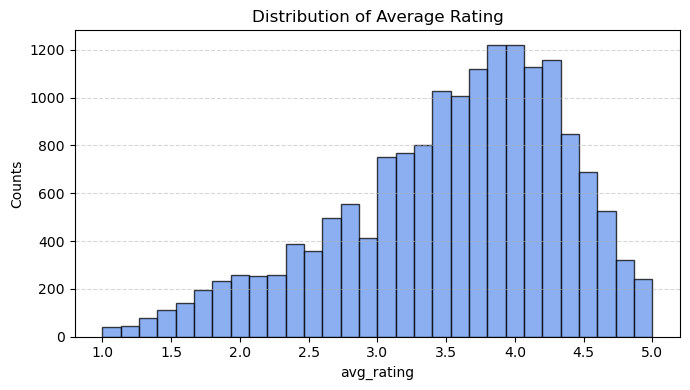

In [34]:
plot_numeric_hist(basic, "avg_rating", title = "Distribution of Average Rating", save_path = fig_path)

Compare to original "stars" provided in the business dataset

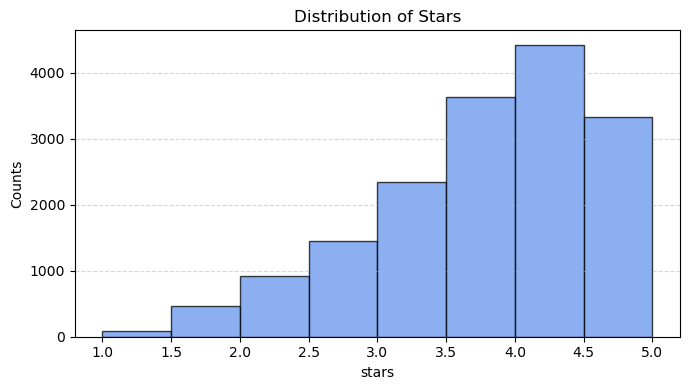

In [35]:
plot_numeric_hist(basic, "stars", bins = 8, title = "Distribution of Stars")

### Distribution of numerical features

Plot the distribution of distance to city center

Definately a need to winsorize distance.

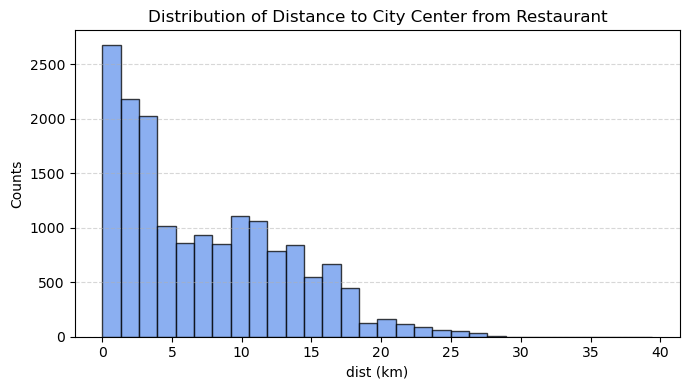

In [36]:
plot_numeric_hist(basic, "dist", bins = 30, unit = "(km)",  title = "Distribution of Distance to City Center from Restaurant")

Plot the distribution of restaurant name length

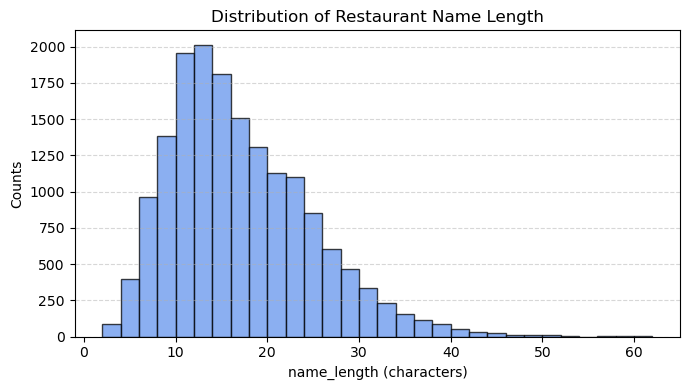

In [37]:
plot_numeric_hist(basic, "name_length", unit = "(characters)",  title = "Distribution of Restaurant Name Length")

Plot the distribution of openning days

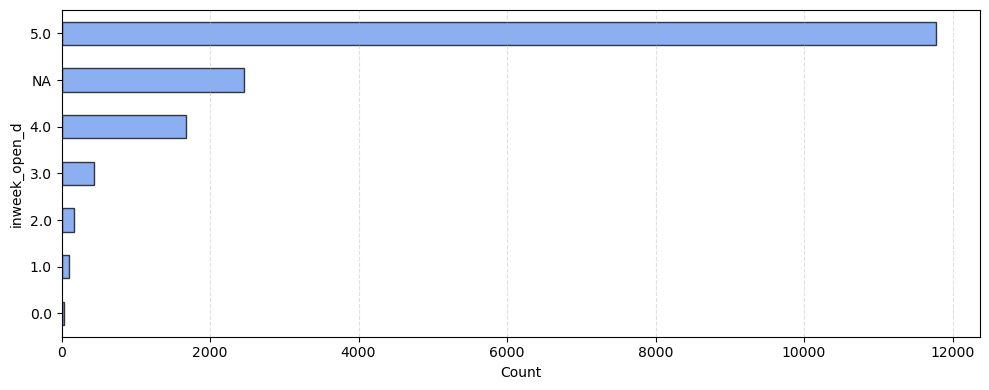

In [38]:
plot_horizontal_bar_counts(times, "inweek_open_d")

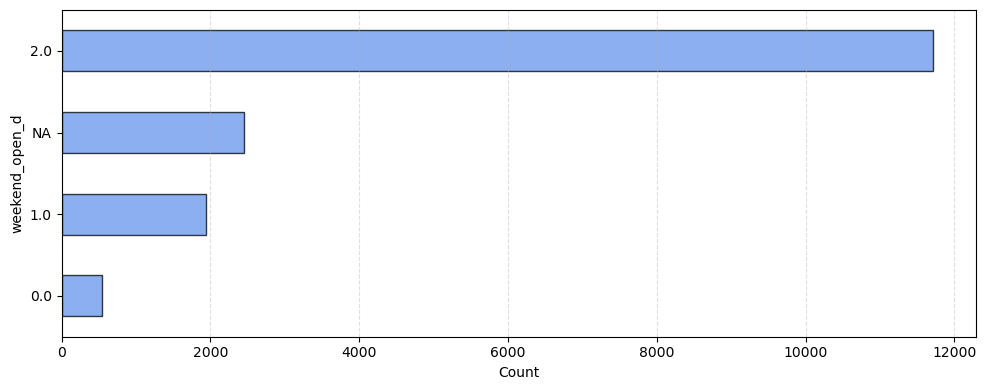

In [39]:
plot_horizontal_bar_counts(times, "weekend_open_d")

Plot the distribution of openning hours

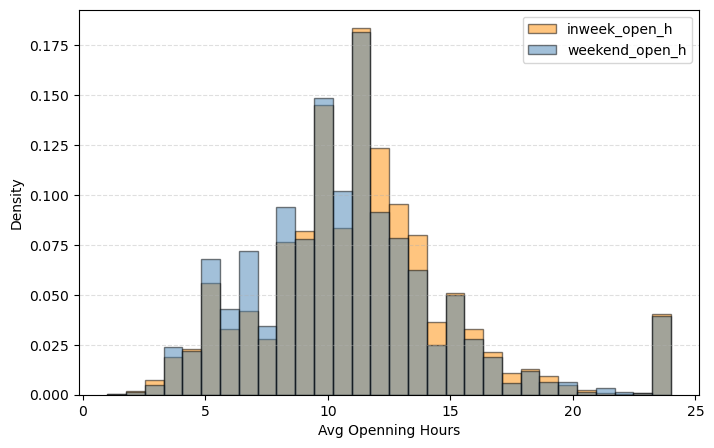

In [40]:
plot_two_histograms(times, "inweek_open_h", "weekend_open_h", xlabel = "Avg Openning Hours")

Plot the distribution of open time

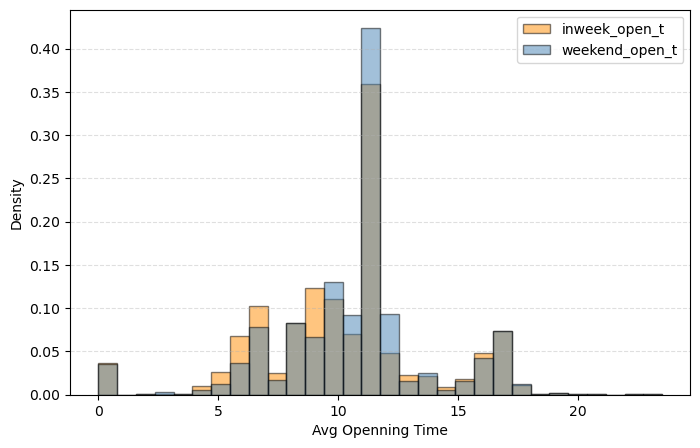

In [41]:
plot_two_histograms(times, "inweek_open_t", "weekend_open_t", xlabel = "Avg Openning Time")

### Distribution of categorical feature

#### City:

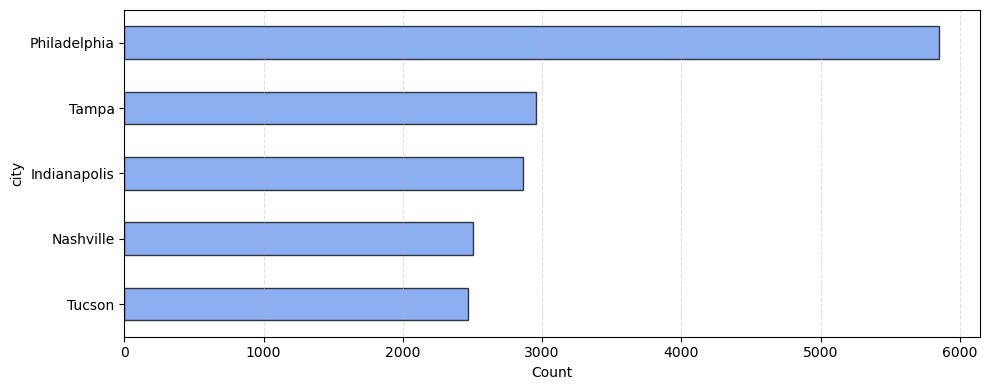

In [42]:
plot_horizontal_bar_counts(basic, "city")

#### For attribute in "attributes" sub-dataframe:

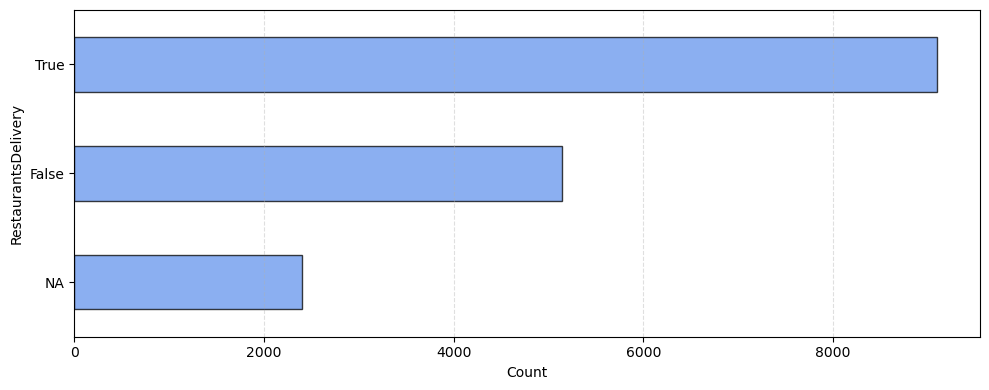

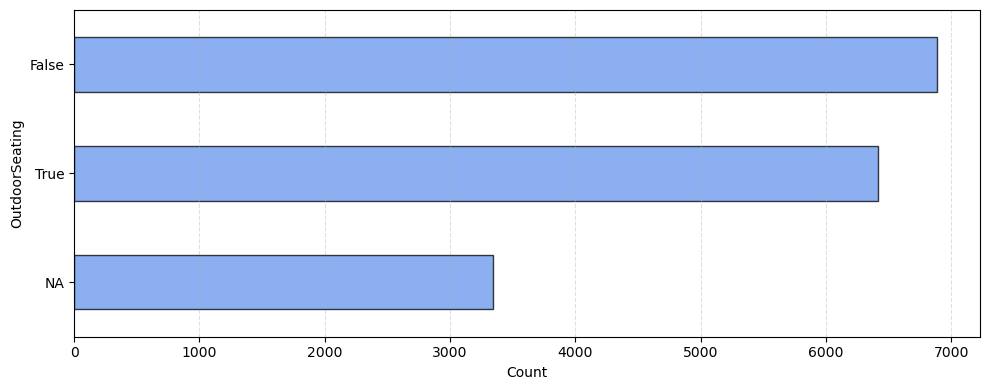

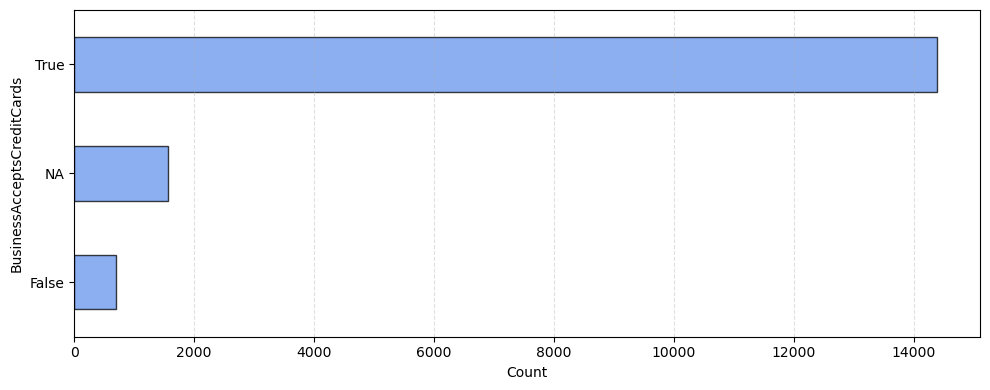

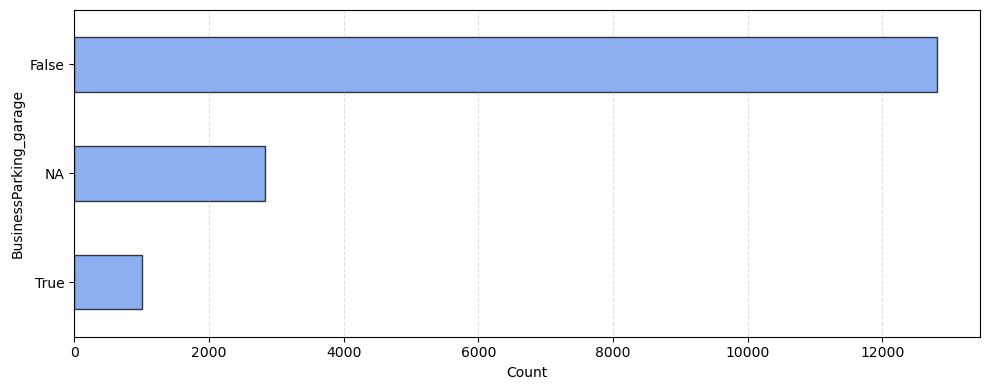

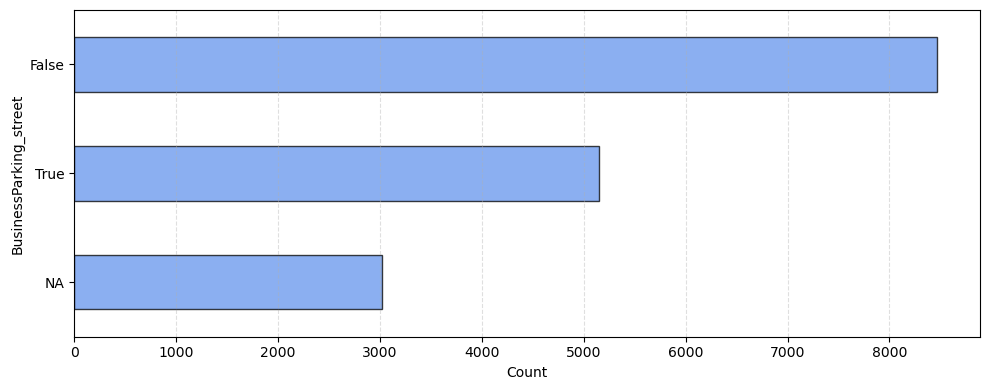

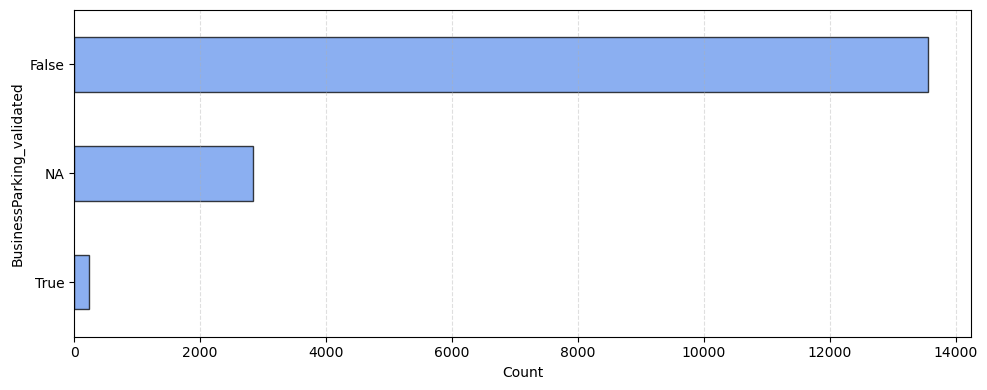

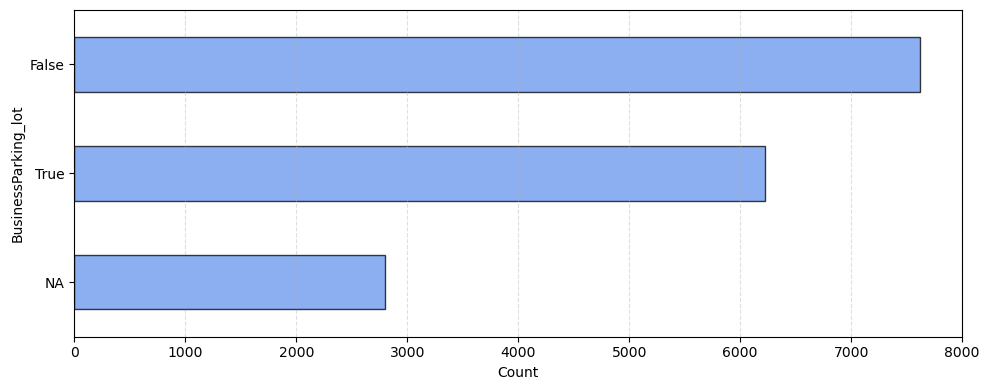

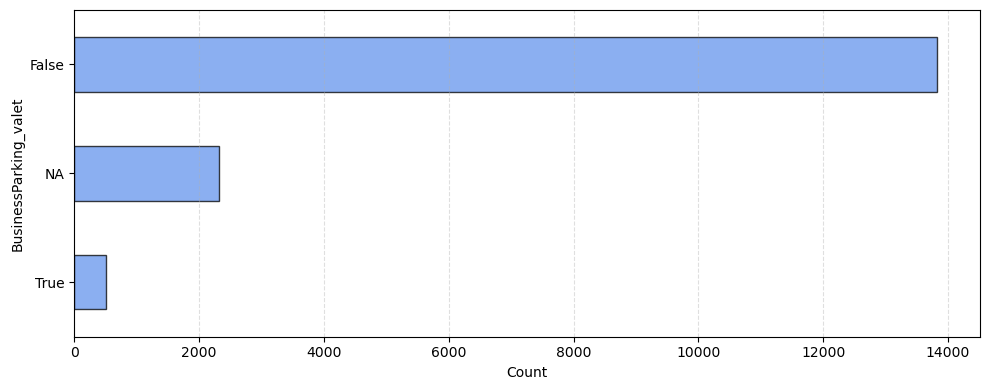

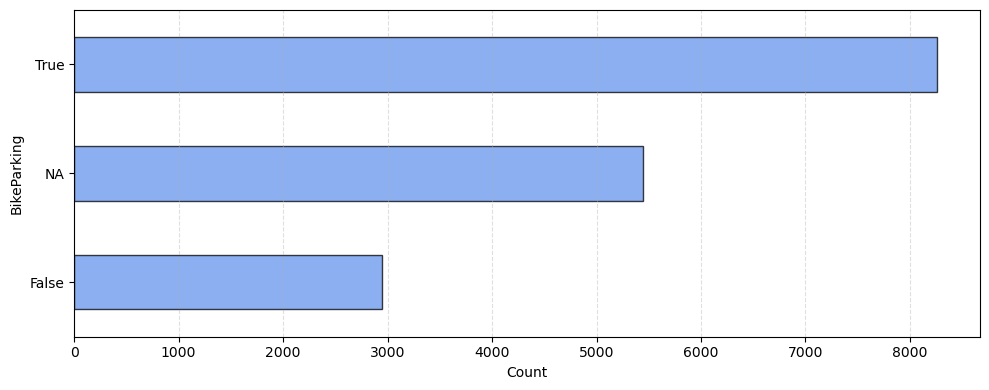

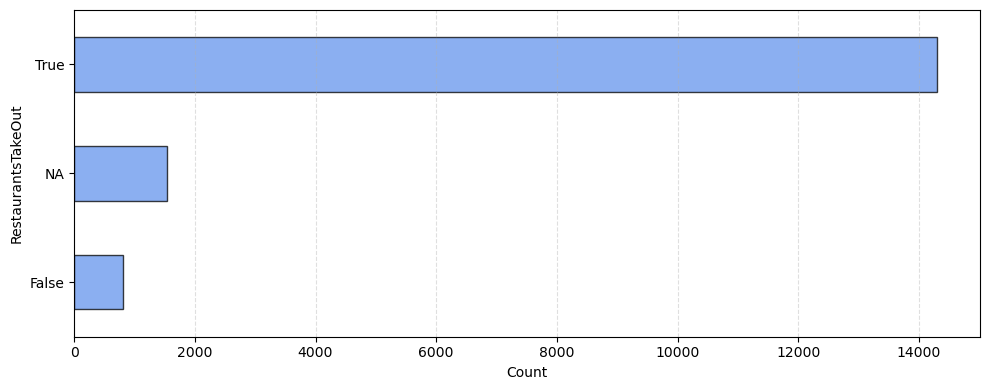

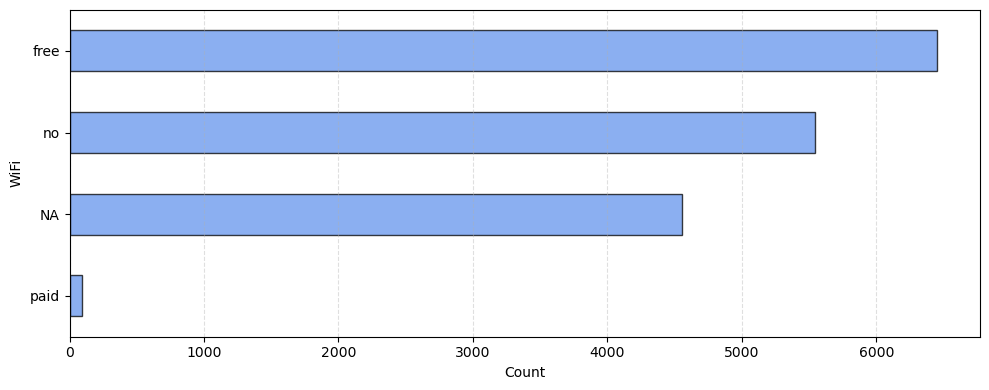

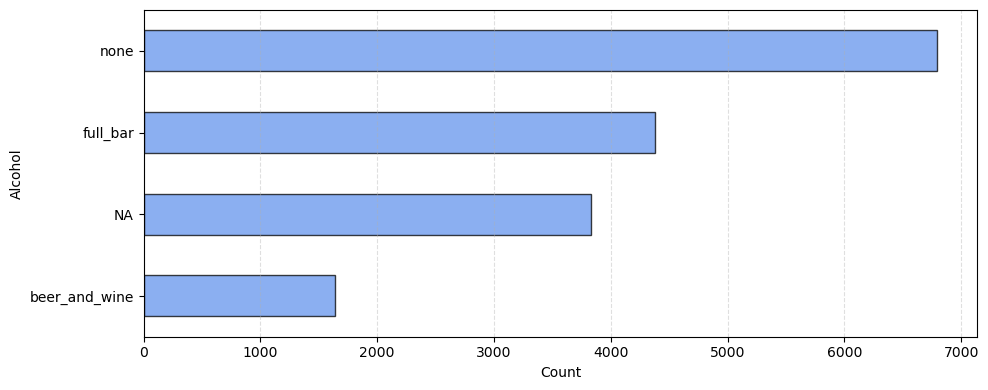

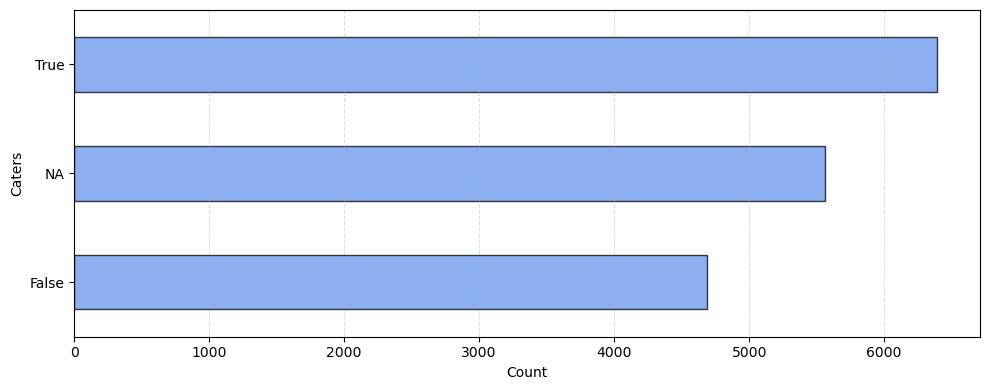

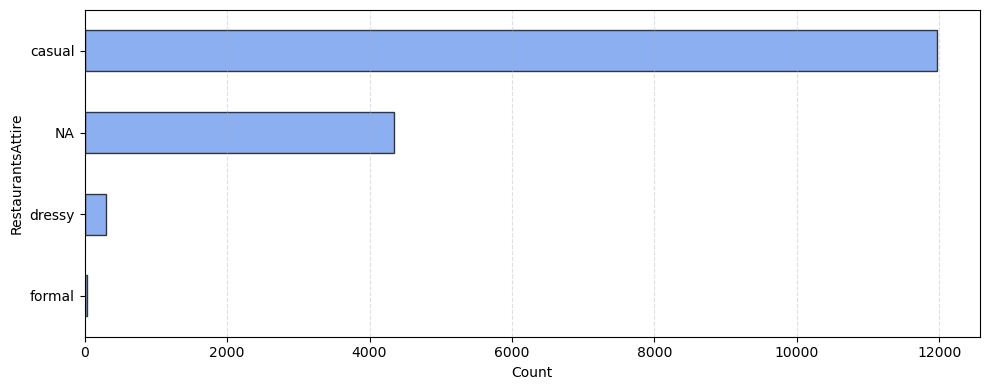

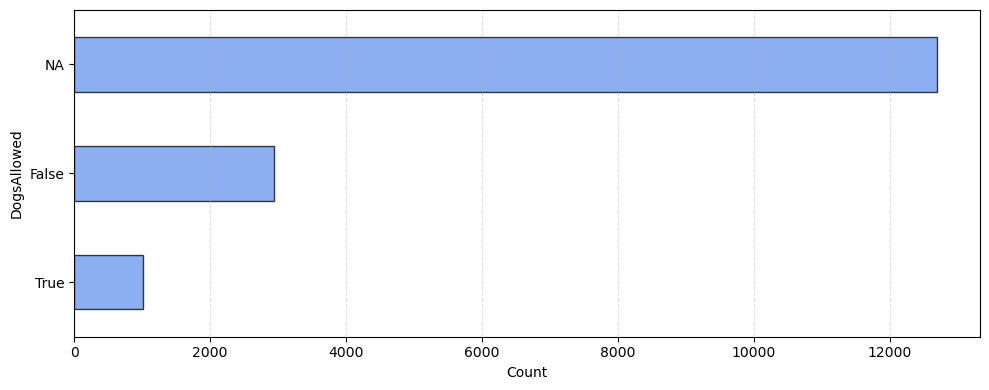

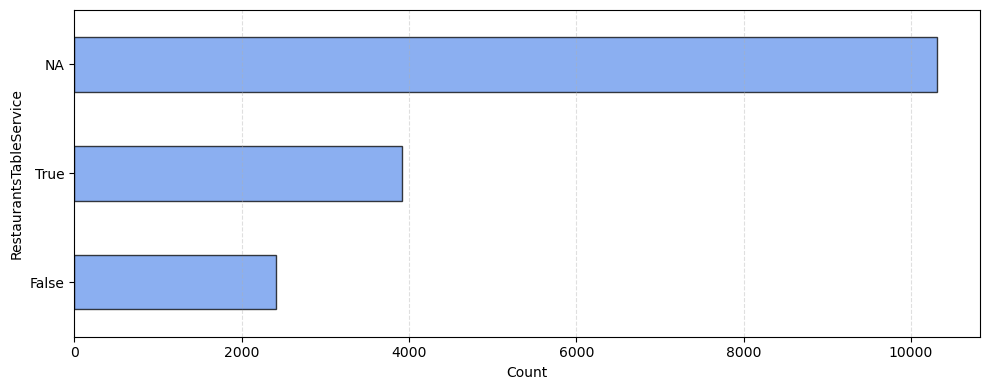

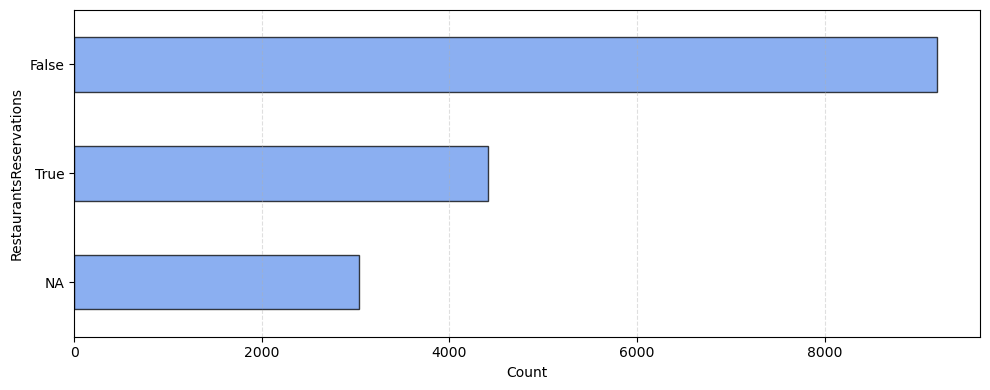

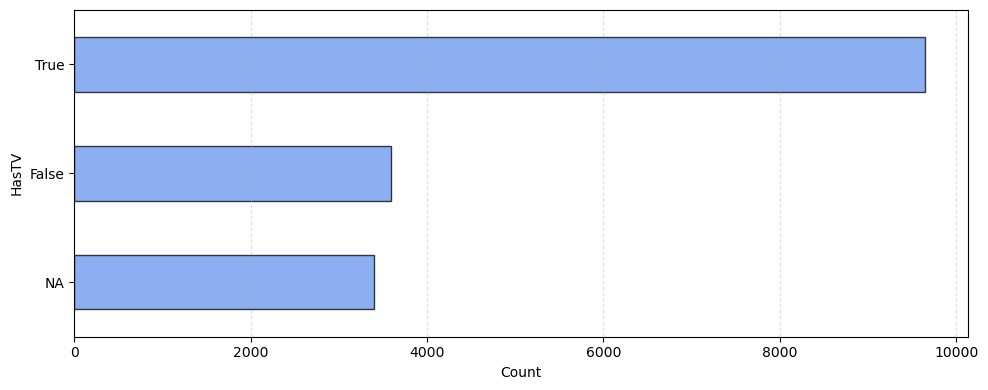

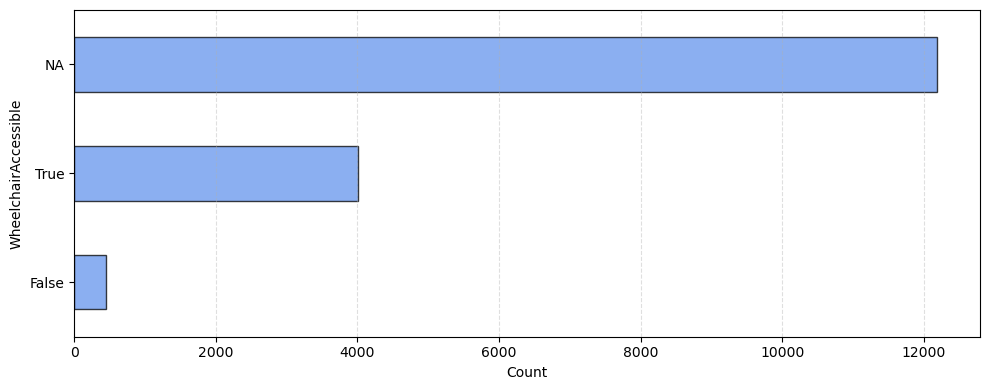

In [ ]:
# plot distribution of each attribute
for col in attributes.iloc[:, 1:].columns:
    plot_horizontal_bar_counts(attributes, col)

#### For category in "categories" sub-dataframe

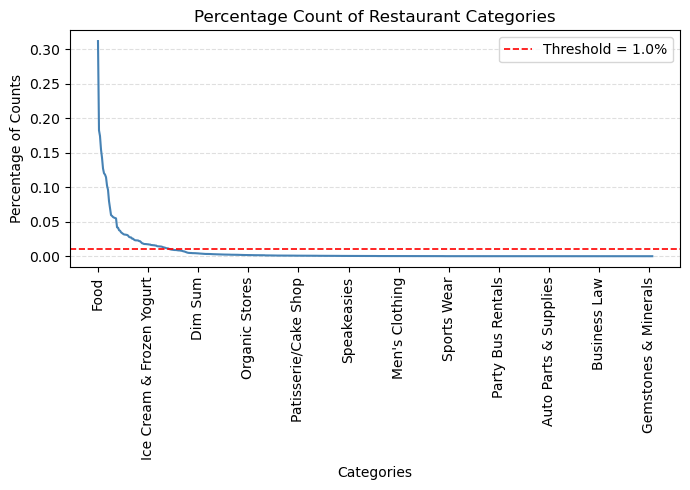

In [44]:
plot_dummy_percentages(categories, categories.iloc[:, 1:].columns, threshold = 0.01, title = "Percentage Count of Restaurant Categories", save_path = fig_path)

- Many categories have less than 1% frequency
- Including them will probarbily lead to over-fitting
- Besides, many of these rare categories are not sensible for restaurant
- Hence, in feature engineering, we will move categories with less than 1% occurence to residual category

### Categorical feature correlation analysis

#### Attributes:

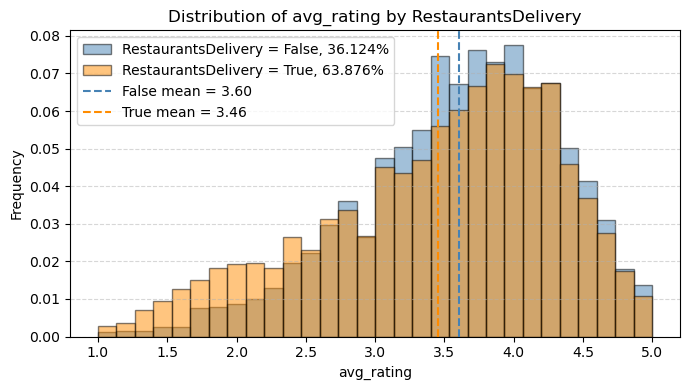

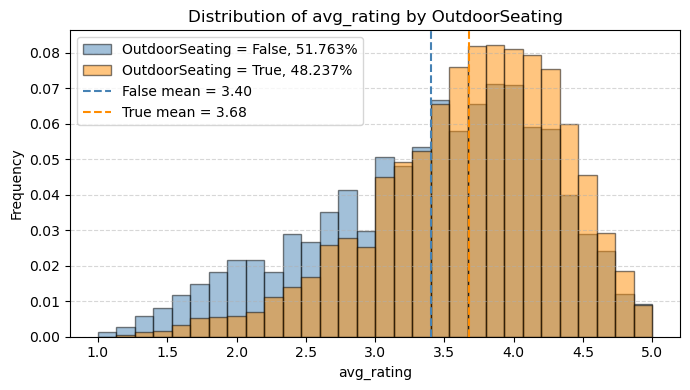

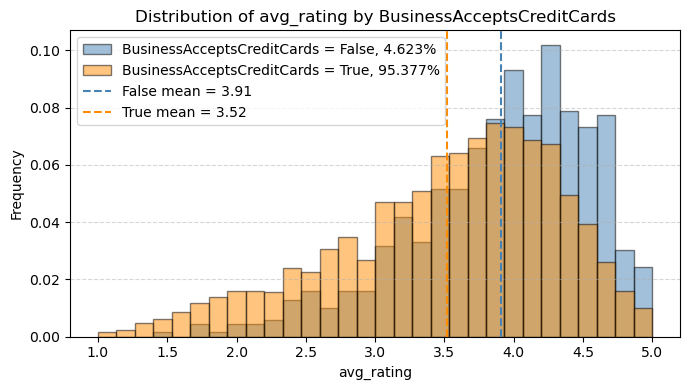

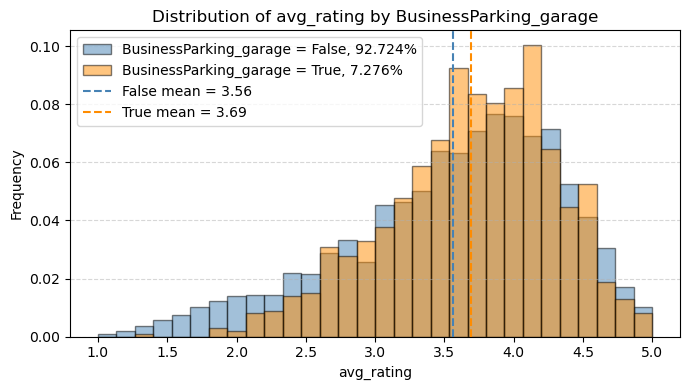

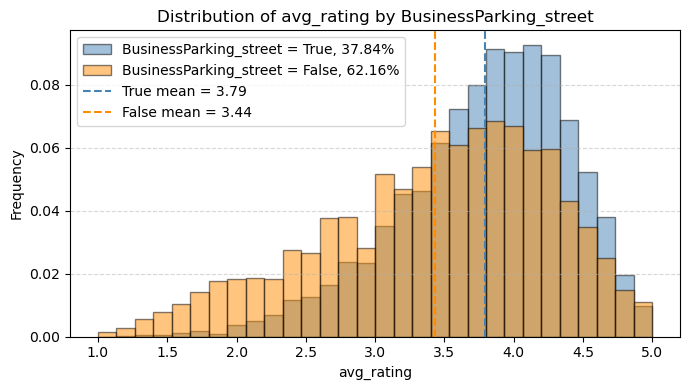

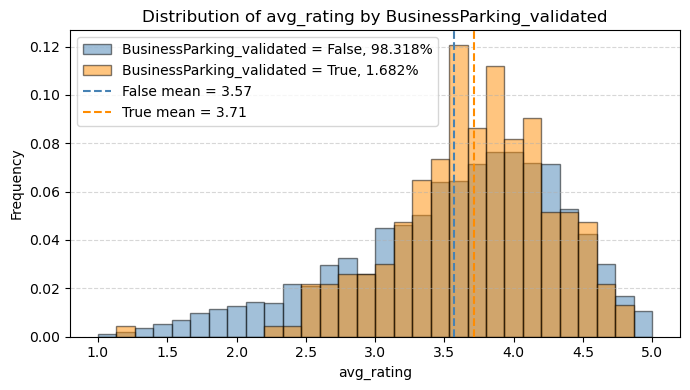

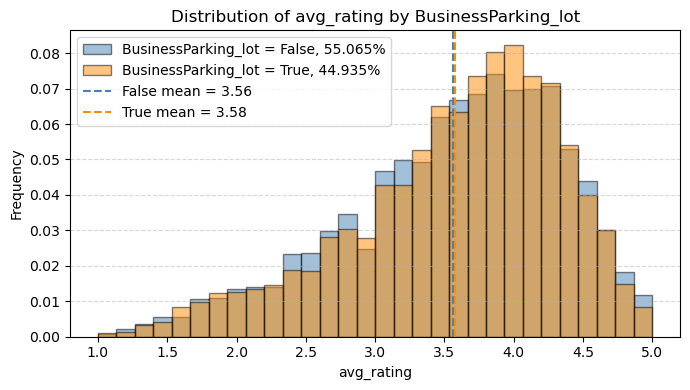

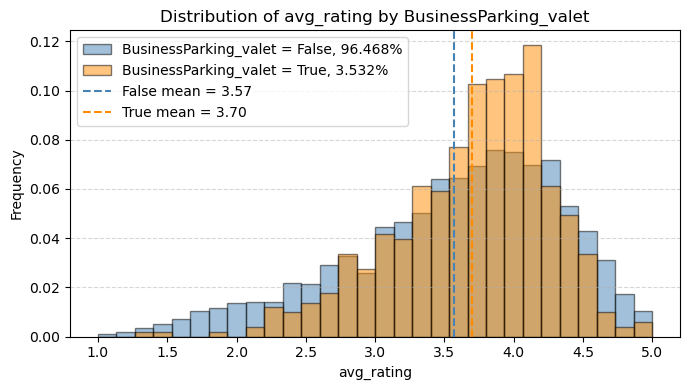

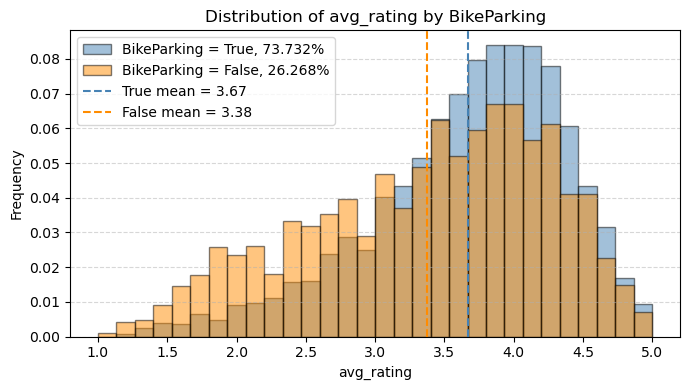

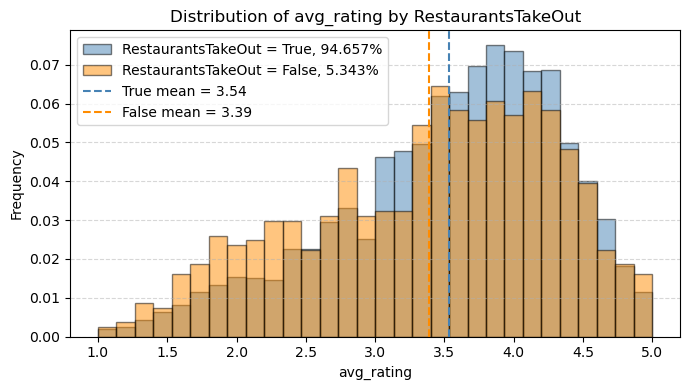

<Figure size 700x400 with 0 Axes>

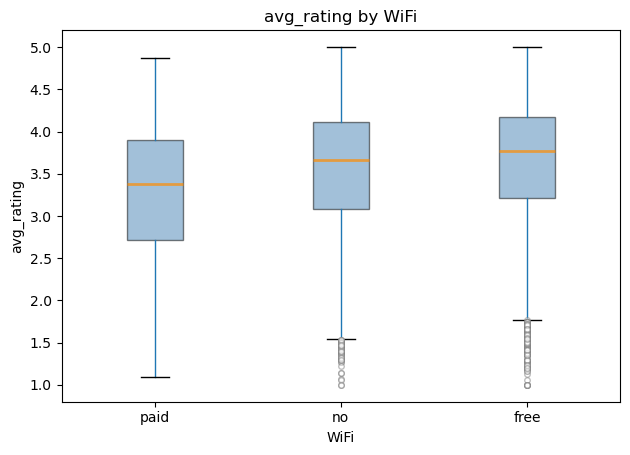

<Figure size 700x400 with 0 Axes>

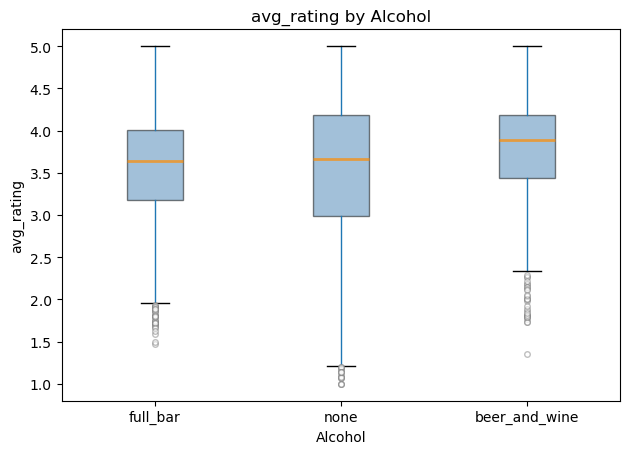

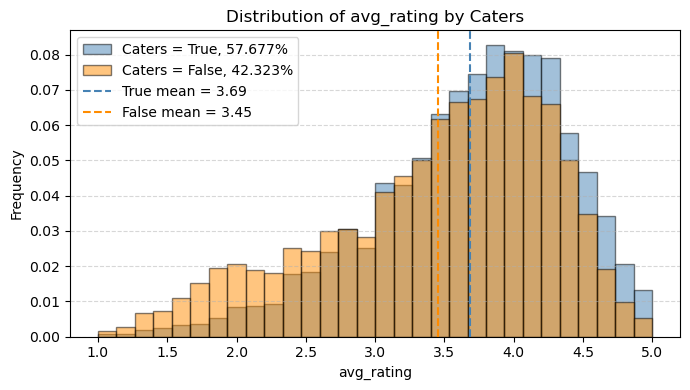

<Figure size 700x400 with 0 Axes>

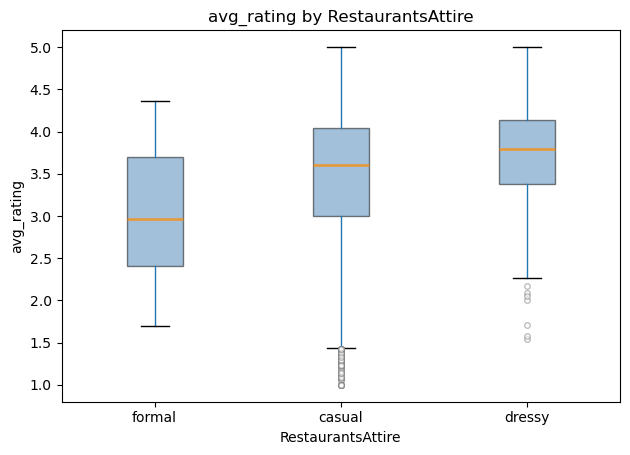

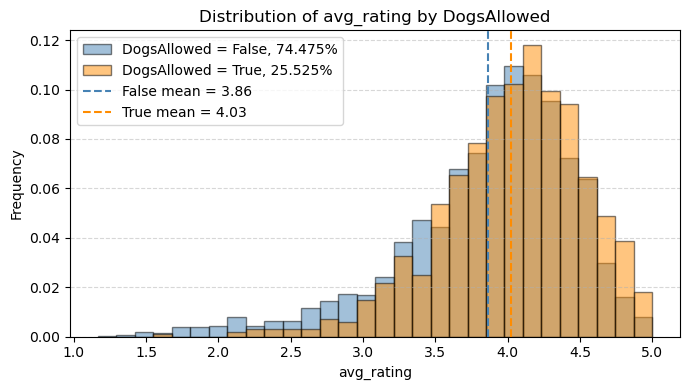

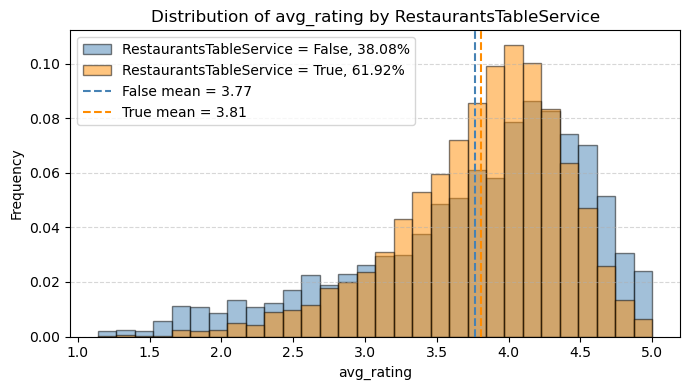

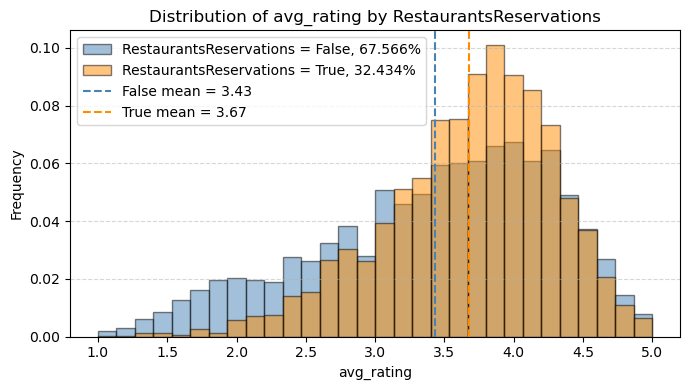

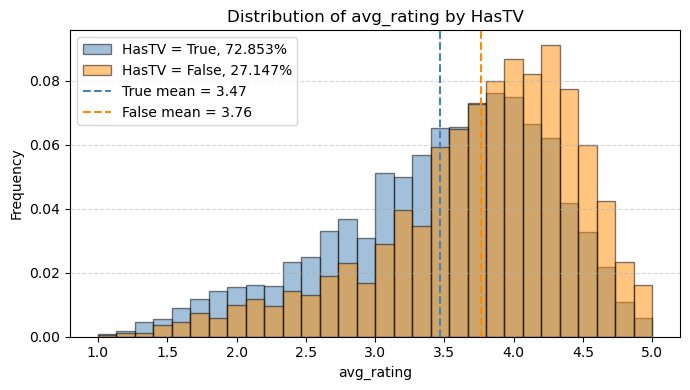

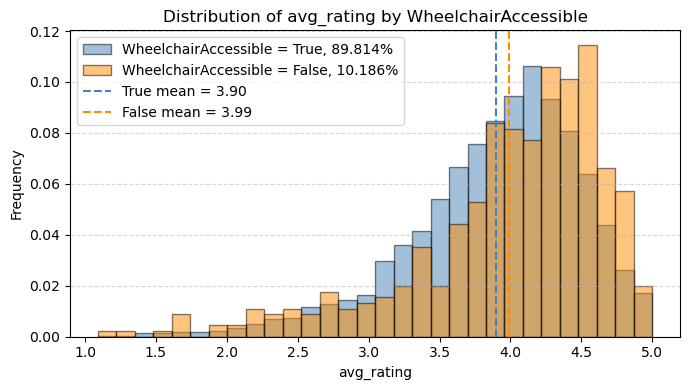

In [ ]:
# generate a temporary dataframe through merging basic sub-dataframe with attributes sub-dataframe
temp = pd.merge(basic, attributes, on="business_id", how="inner")

# plot distribution of average rating by attribute
for col in attributes.iloc[:, 1:].columns:
    if len(attributes[col].unique()) <= 3:
        plot_hist_by_twocategory(temp, "avg_rating", col)
    else:
        boxplot_avg_rating_by_group(temp, "avg_rating", col, include_na_group = False)

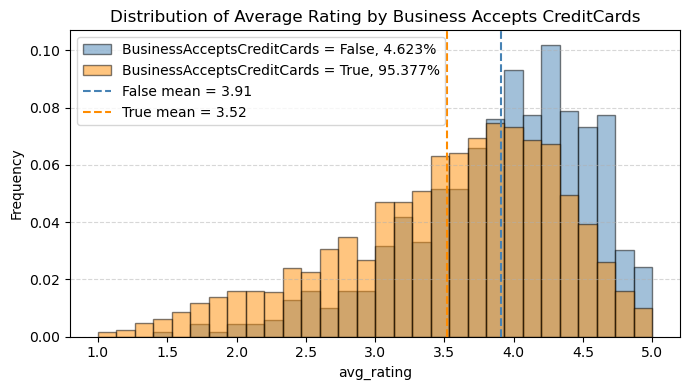

In [46]:
plot_hist_by_twocategory(temp, "avg_rating", "BusinessAcceptsCreditCards", title = "Distribution of Average Rating by Business Accepts CreditCards", save_path = fig_path)

Comparision on NA / not NA values

<Figure size 700x400 with 0 Axes>

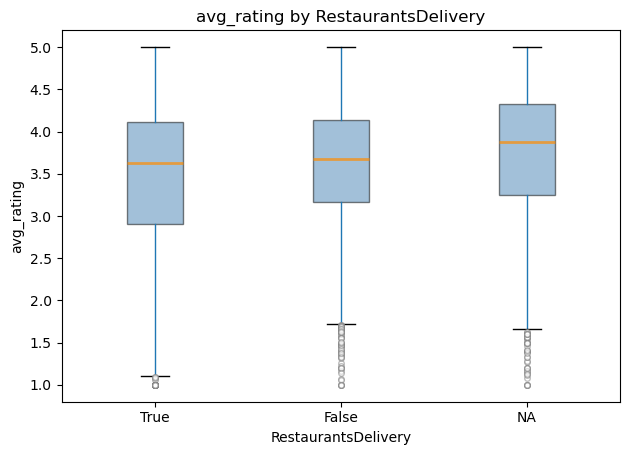

<Figure size 700x400 with 0 Axes>

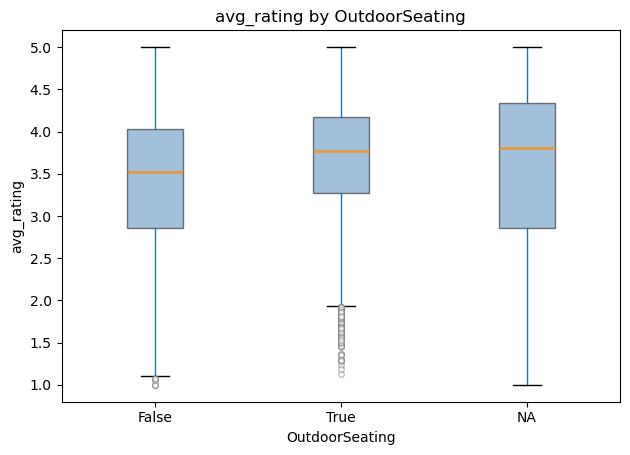

<Figure size 700x400 with 0 Axes>

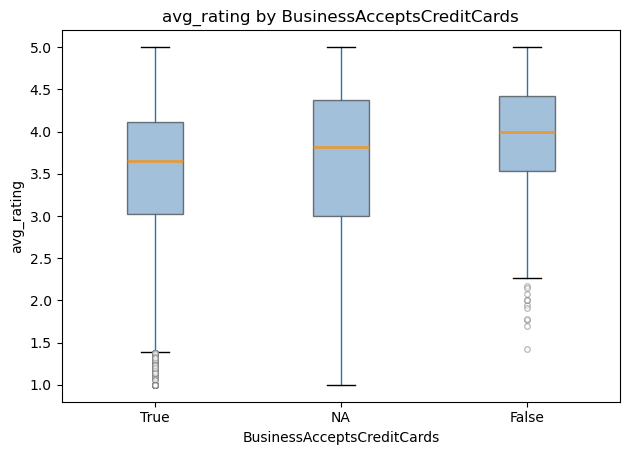

<Figure size 700x400 with 0 Axes>

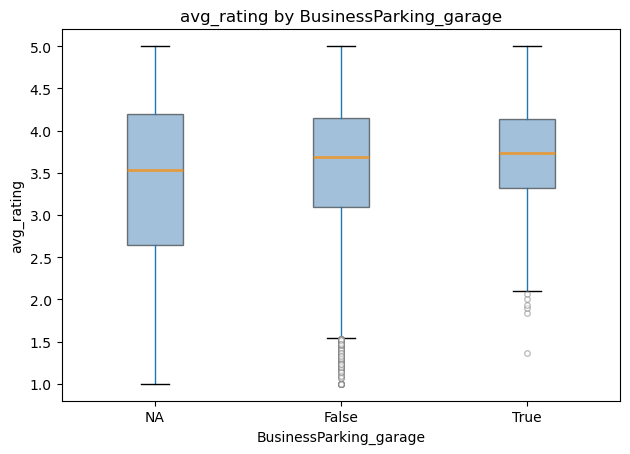

<Figure size 700x400 with 0 Axes>

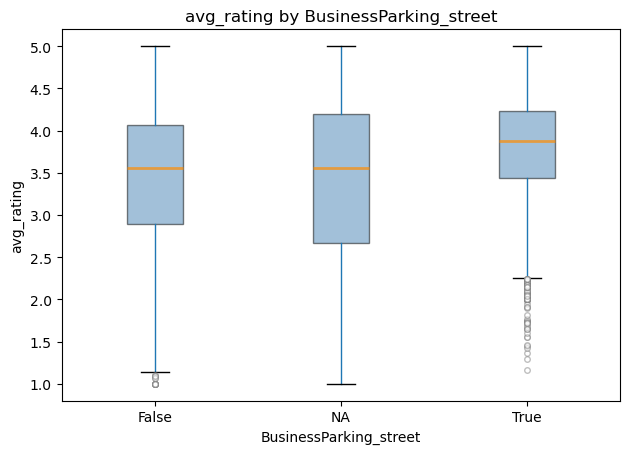

<Figure size 700x400 with 0 Axes>

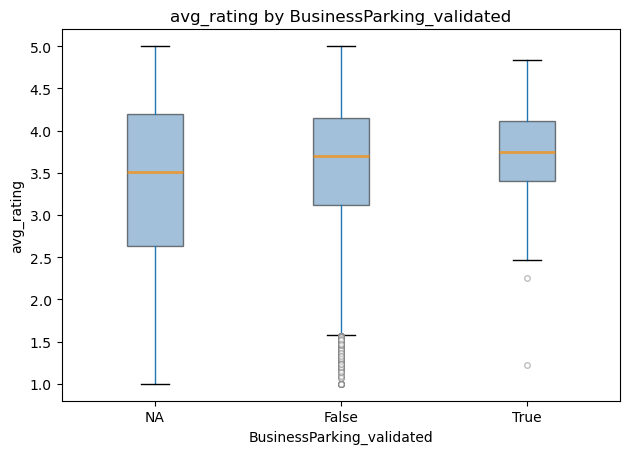

<Figure size 700x400 with 0 Axes>

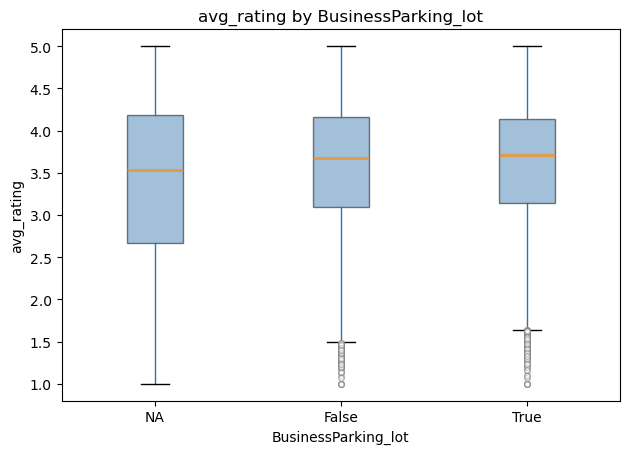

<Figure size 700x400 with 0 Axes>

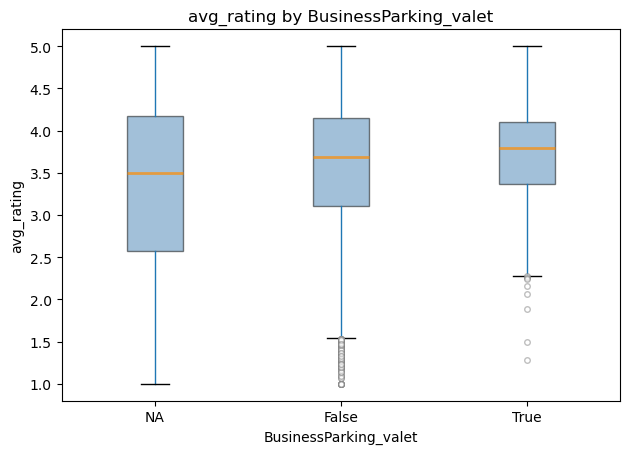

<Figure size 700x400 with 0 Axes>

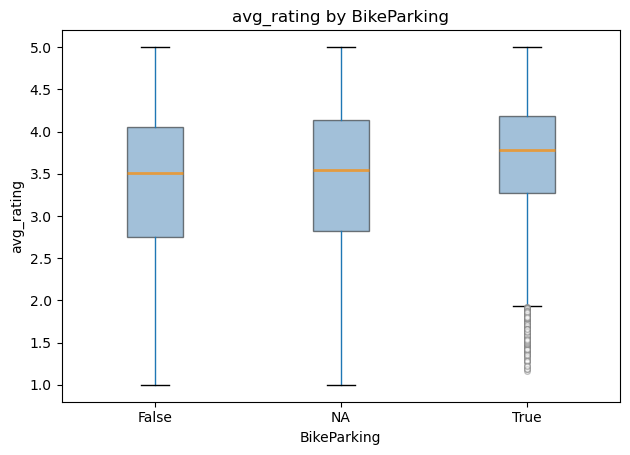

<Figure size 700x400 with 0 Axes>

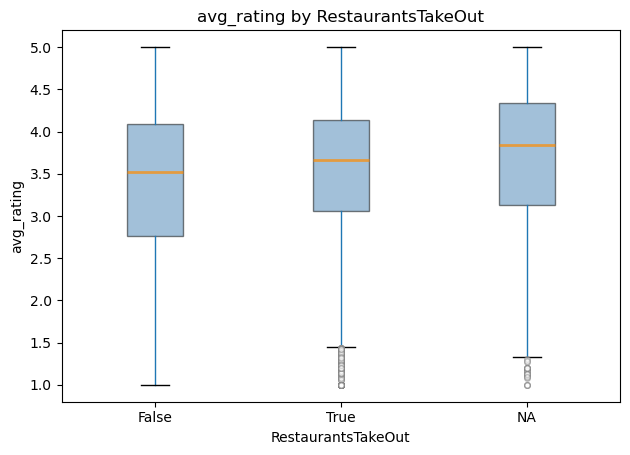

<Figure size 700x400 with 0 Axes>

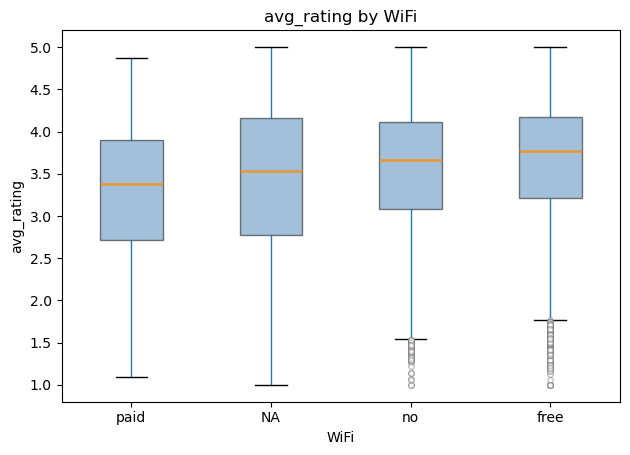

<Figure size 700x400 with 0 Axes>

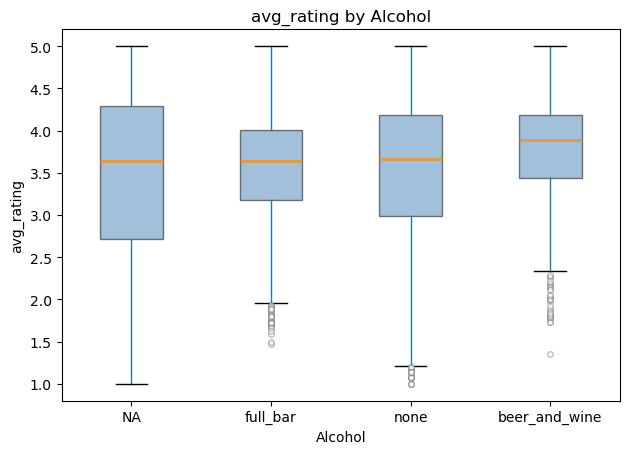

<Figure size 700x400 with 0 Axes>

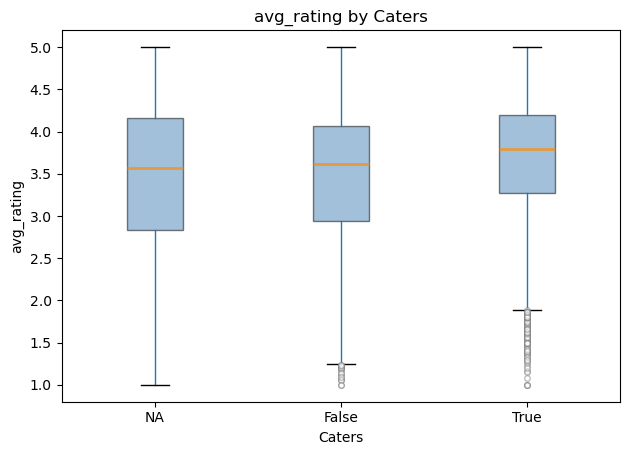

<Figure size 700x400 with 0 Axes>

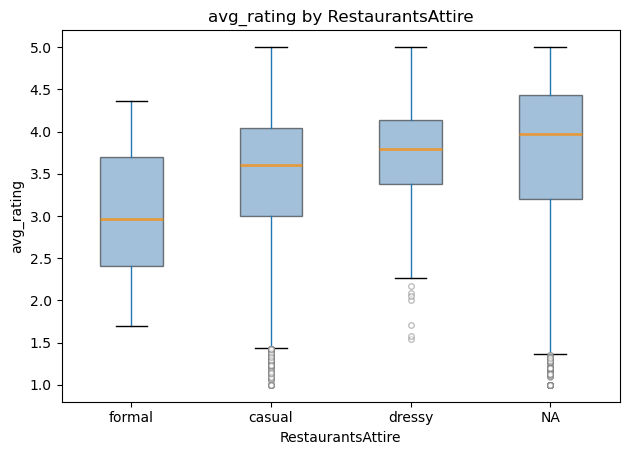

<Figure size 700x400 with 0 Axes>

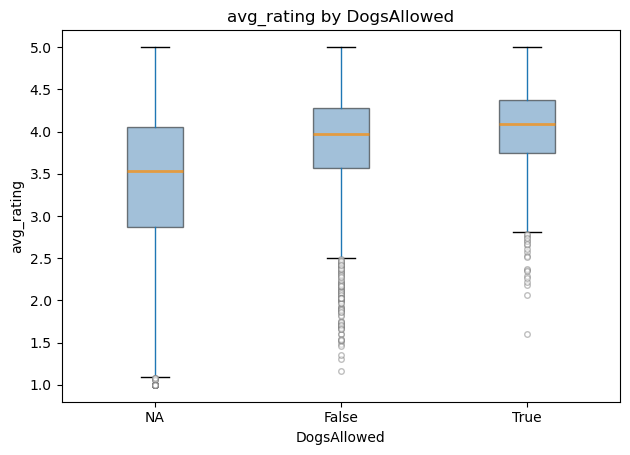

<Figure size 700x400 with 0 Axes>

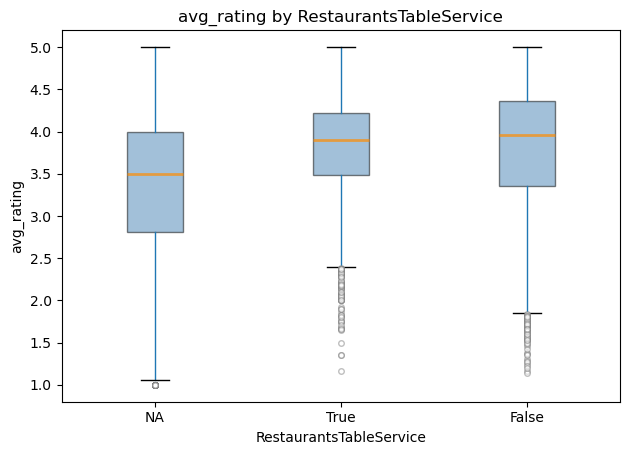

<Figure size 700x400 with 0 Axes>

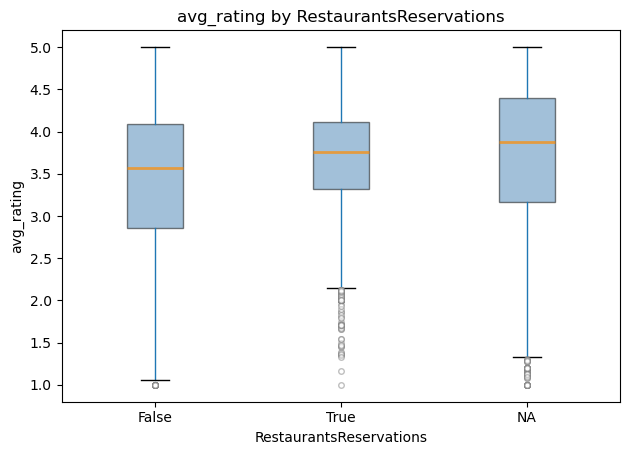

<Figure size 700x400 with 0 Axes>

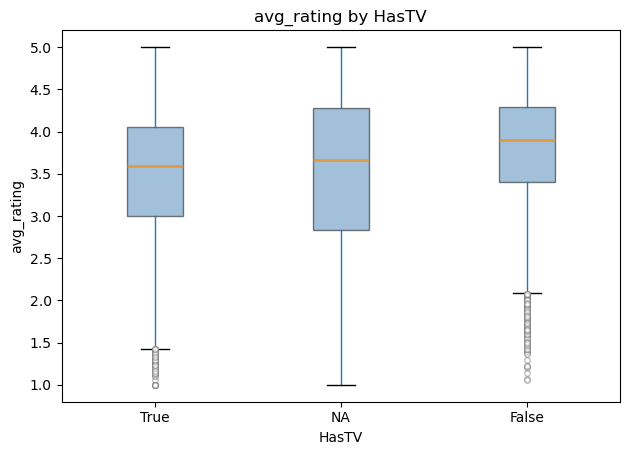

<Figure size 700x400 with 0 Axes>

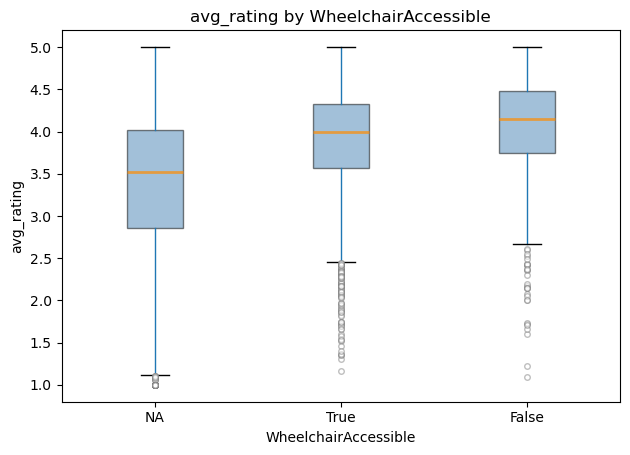

In [47]:
# generate a temporal dataframe
temp = pd.merge(basic, attributes, on="business_id", how="inner").fillna("NA")

# plot distribution of average rating by attribute and NA
for col in attributes.iloc[:, 1:].columns:
    boxplot_avg_rating_by_group(temp, "avg_rating", col)

#### City:

<Figure size 700x400 with 0 Axes>

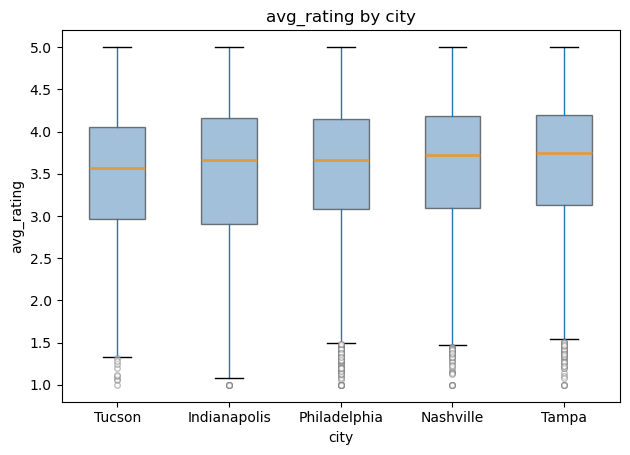

In [48]:
boxplot_avg_rating_by_group(basic, "avg_rating", "city")

### Numerical feature correlation analysis

#### Distance to city center

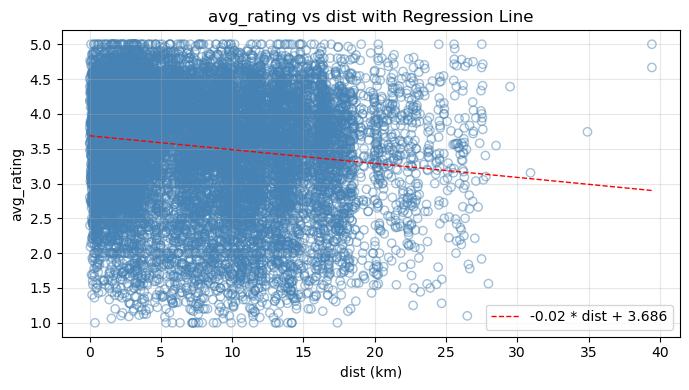

In [49]:
scatter_plot_with_reg(basic, "dist", "avg_rating", unit = "km")

#### Name length

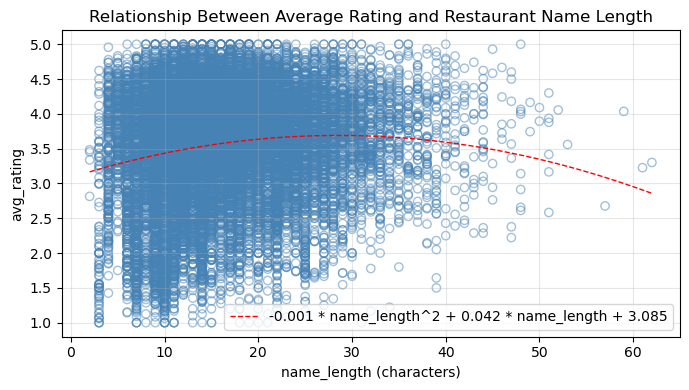

In [50]:
scatter_plot_with_quad_reg(basic, "name_length", "avg_rating", unit = "characters",  title = "Relationship Between Average Rating and Restaurant Name Length", save_path = fig_path)

#### Openning hours

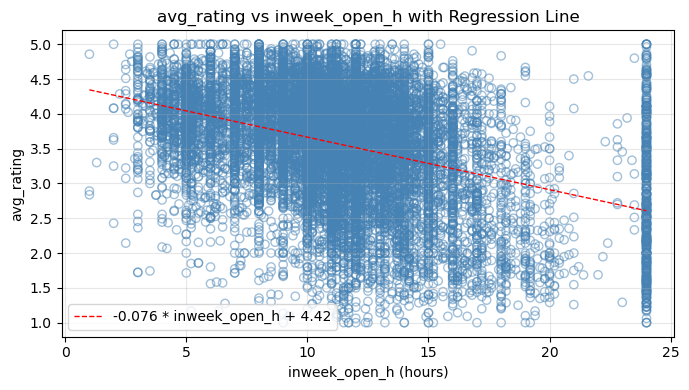

In [51]:
temp = pd.merge(basic, times, on="business_id", how="inner")
scatter_plot_with_reg(temp, "inweek_open_h", "avg_rating", unit = "hours")

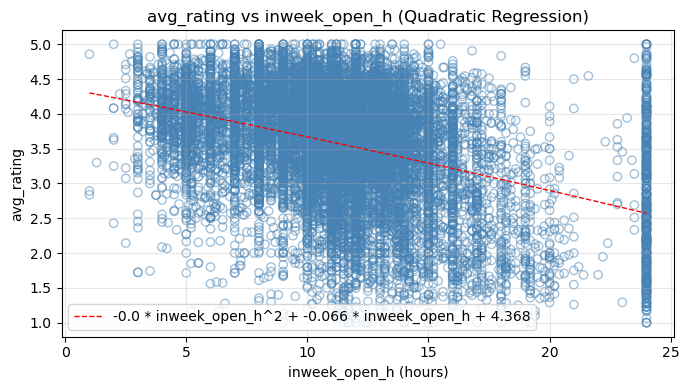

In [52]:
scatter_plot_with_quad_reg(temp, "inweek_open_h", "avg_rating", unit = "hours")

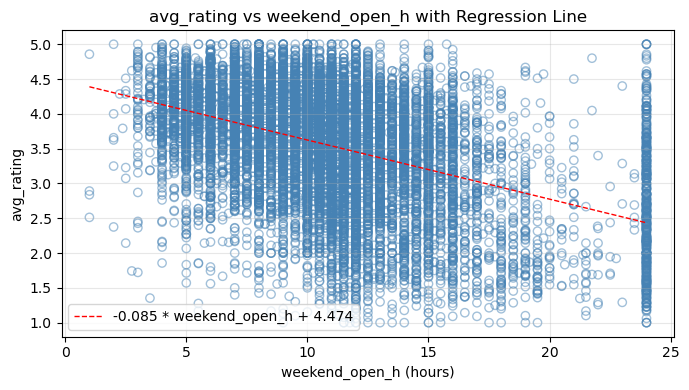

In [53]:
scatter_plot_with_reg(temp, "weekend_open_h", "avg_rating", unit = "hours")

#### Open time

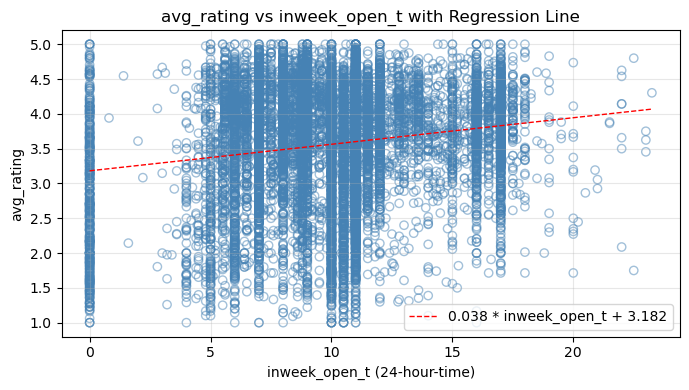

In [54]:
scatter_plot_with_reg(temp, "inweek_open_t", "avg_rating", unit = "24-hour-time")

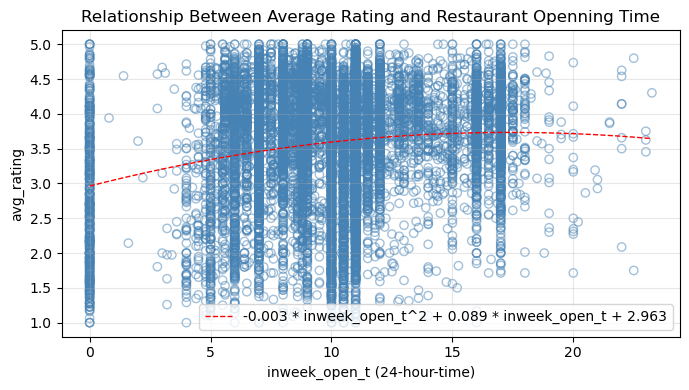

In [55]:
scatter_plot_with_quad_reg(temp, "inweek_open_t", "avg_rating", unit = "24-hour-time", title = "Relationship Between Average Rating and Restaurant Openning Time", save_path = fig_path)

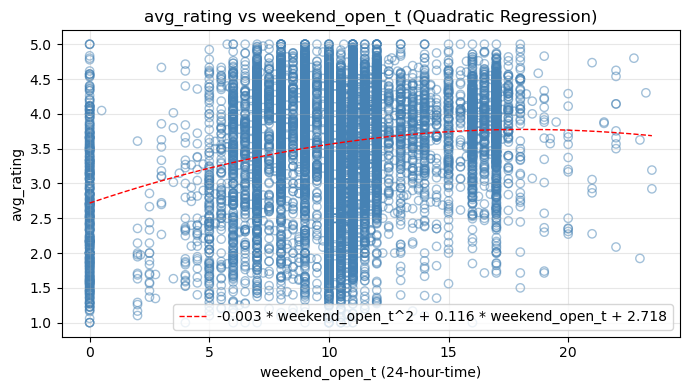

In [56]:
scatter_plot_with_quad_reg(temp, "weekend_open_t", "avg_rating", unit = "24-hour-time")

#### Missing values in times

In [57]:
print(report_missings(times))

0    business_id                        |object                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    inweek_open_d                      |float64                       |Mis_count: 2455               |Uni_value: Mis_pct: 0.14751832712414373
2    weekend_open_d                     |float64                       |Mis_count: 2455               |Uni_value: Mis_pct: 0.14751832712414373
3    inweek_open_h                      |float64                       |Mis_count: 2490               |Uni_value: Mis_pct: 0.14962143973080158
4    weekend_open_h                     |float64                       |Mis_count: 2993               |Uni_value: Mis_pct: 0.17984617233505587
5    inweek_open_t                      |float64                       |Mis_count: 2490               |Uni_value: Mis_pct: 0.14962143973080158
6    weekend_open_t                     |float64                       |Mis_count: 2993               |Uni_value: Mis_pct: 0.17984617233505587



There are three causes of missing values in time measures:
1. if inweek_opend_d and weekend_open_d are missed: the restaurant completely do not provide any info on openning and closing time (14.7%)
2. if inweek_open_h and inweek_open_t are missed: the restaurant do not open during weekdays (0.2%)
3. if weekend_open_h and weekend_open_t are missed: the restaurant do not open during weekend (3.2%)

We can analyze all of these three cases simply based on value of inweek_open_d and weekend_open_d:
1. in the first case, inweek_open_d & weekend_open_d = NA
2. in the second case, inweek_open_d = 0
3. in the third case, weekend_open_d = 0

We can test whether there is a systematic difference in avg_rating across these 3 case:

<Figure size 700x400 with 0 Axes>

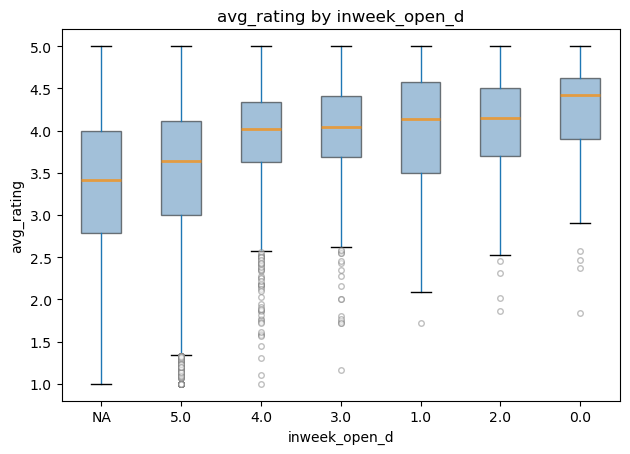

In [58]:
temp = pd.merge(basic, times, on="business_id", how="inner")
boxplot_avg_rating_by_group(temp, "avg_rating", "inweek_open_d", include_na_group=True)

<Figure size 700x400 with 0 Axes>

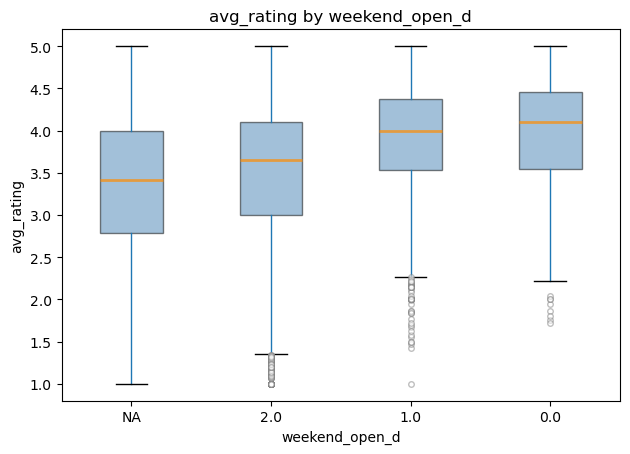

In [59]:
boxplot_avg_rating_by_group(temp, "avg_rating", "weekend_open_d", include_na_group=True)

## Feature Selection

### basic
- we can drop stars as it is not an avaliable feature for predcition
- we keep the "city" feature; although it does not lead to much variation in avg_rating, it might have an effect through interaction with other variables
- name_length has a quadratic relation with avg_rating
- dist is negatively correlated with rating

In [60]:
basic = basic.drop(columns=["stars"])
basic["city"] = basic["city"].astype("string")

### attributes
- All attributes seem to have some correlation with the average rating (e.g. induce higher mean or more concentrated distribution)
- Hence, we will not drop any of them
- However, at this moment, we need to encode NA values to "NA" category

In [61]:
attributes = attributes.fillna("NA")
print(report_missings(attributes))

0    business_id                        |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RestaurantsDelivery                |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    OutdoorSeating                     |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    BusinessAcceptsCreditCards         |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    BusinessParking_garage             |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
5    BusinessParking_street             |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    BusinessParking_validated          |string                        |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    BusinessParking_lot                |string                        |Mis_count: 0                  |Uni_valu

### categories
- we have too many one-hot encoded categories
- we will move those with density below 1% to a residual category at the feature engineering step

### times
- we will keep inweek_opend_d and weekend_open_d, as they capture a small set of restaurants that do not open during weekend () / weekday ()
- we will keep inweek_open_h and weekend_open_h as they are negatively correlated with avg_rating (working more hours, lower service quality? or because 24hours openning restaurants are in lower popularity e.g. worse ambience)
- we will also keep inweek_open_t and weekend_open_t, as there is a quadratic relationship between these features and avg_rating
- we need to convert inweek_opend_d and weekend_open_d to categorical variable, as these numerical variable only have limited set of unique values
- we will also add a missing value indicator hour_missing to indicate that openning hours are missed from these restaurants (in turn, missing is correlated with lower rating)

In [62]:
times["missing_h"] = times["inweek_open_d"].apply(lambda x: 1 if pd.isna(x) else 0)

## Export Cleaned Dataset

It is now the time to export the cleaned dataset with selected features

### Merge sub-dataframes

In [63]:
cleaned_data = (
    basic
    .merge(attributes, on="business_id", how="inner")
    .merge(times, on="business_id", how="inner")
    .merge(categories, on="business_id", how="inner")
)

### Export as parquet file

In [64]:
clean_data_path = data_path/"cleaned_data.parquet"
cleaned_data.to_parquet(clean_data_path)

## Exporting plot

<Figure size 700x400 with 0 Axes>

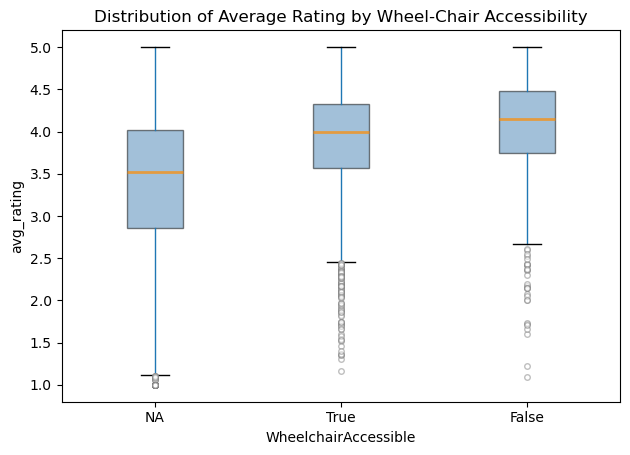

In [65]:
boxplot_avg_rating_by_group(cleaned_data, "avg_rating", "WheelchairAccessible", title = "Distribution of Average Rating by Wheel-Chair Accessibility", save_path = fig_path)